<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_13_extendedPAIRS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercise 13 — extended PAIRS: unbinned representations and fast frequentist inference

We start from the controlled misspecification in **Exercise 7** and implement three pieces:

1. Learn an event encoder using singletons and pairs, then freeze it to represent full unbinned experiments.
2. Learn the simulator-to-reference response map with an amortized population fit.
3. Train fast estimator and test-statistic heads on cached full-experiment embeddings.

Each piece has a numerical comparison with the direct unbinned calculation. **This notebook stops before distribution-flow training and Neyman calibration.** Agreement with a likelihood teacher is not a coverage statement.

Our starting point is [PAIRS, *It Just Takes Two*](https://arxiv.org/abs/2605.07972): train a mean-pool encoder at set sizes one and two, freeze it, and train an inference head on full-set embeddings. Here we adapt that strategy to a discrete auxiliary posterior, a population response fit, and frequentist regression heads. These extensions are our prototype, not results established by PAIRS. Its sufficiency theorem does not automatically apply to this finite, imperfectly trained representation. [LF2I](https://arxiv.org/abs/2107.03920) motivates the later separation of statistic learning, calibration, and coverage diagnostics.

This first example has **one signal-strength parameter and no nuisance parameters**. Its simplicity lets us test every component before extending the parameter space. No event histogram or $q$ binning is used.

**Prerequisites:** run Exercise 5 to save its PRESEL, reference-flow and ratio checkpoints, and run Exercise 7 through loading the PRESEL state. We reuse those frozen models without retraining them. Use a GPU runtime and the same Google Drive workspace. The `full` configuration retains Exercise 7's nominal event yields; `quick` reduces training and bank sizes, not the event count per experiment.


**This revision:** reuse the completed representation, response and toy caches; compare a signed-root statistic head with a flexible direct-statistic head; train longer with learning-rate reduction; and benchmark the pair posterior against an exact reference calculation. Neither head assumes a quadratic likelihood. The original head is retained as a comparison when its checkpoint exists. The default reuses Rafael's completed run `5f97501b6b87`; on a fresh workspace the notebook builds the prerequisites first.


In [1]:
# Colab setup: a separate source checkout, the same persistent model workspace.
import os
import sys
import subprocess
from pathlib import Path

USE_DRIVE = True
REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"
BRANCH = "ml4hep_school_tutorial"
IN_COLAB = "google.colab" in sys.modules

def run(*args, **kwargs):
    subprocess.run([str(a) for a in args], check=True, **kwargs)

if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')
        ROOT = Path('/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab')
    else:
        ROOT = Path('/content')
    SOURCE_DIR = Path('/content/nsbi_extended_pairs_source')
    if not (SOURCE_DIR / '.git').exists():
        env = dict(os.environ, GIT_LFS_SKIP_SMUDGE='1')
        run('git', 'clone', '--depth', '1', '--filter=blob:none', '--sparse',
            '--branch', BRANCH, REPO_URL, SOURCE_DIR, env=env)
        run('git', '-C', SOURCE_DIR, 'sparse-checkout', 'set',
            'src', 'workshops/ml4hep_tifr_colab')
    else:
        run('git', '-C', SOURCE_DIR, 'pull', '--ff-only', 'origin', BRANCH)
    TUTORIAL_DIR = SOURCE_DIR / 'workshops/ml4hep_tifr_colab'
    for directory in (SOURCE_DIR / 'src', TUTORIAL_DIR):
        sys.path.insert(0, str(directory))
    run(sys.executable, '-m', 'pip', 'install', '-q', 'pytorch-lightning',
        'onnx', 'onnxruntime', 'onnxscript', 'iminuit', 'mplhep', 'nflows', 'pyarrow')
    WORK_DIR = ROOT / 'nsbi-lhc-toolkit/workshops/ml4hep_tifr'
    WORK_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(WORK_DIR)
print('Persistent working directory:', Path.cwd())


Mounted at /content/drive
Persistent working directory: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr


In [2]:
import copy
import importlib
import hashlib
import inspect
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
import torch
from scipy.optimize import brentq
from IPython.display import display

from nsbi_common_utils.training.utils import load_trained_model
from utils import FEATURES, predict_with_model
from utils_distributions import background_components, signal_components, smearing_parameters
from utils_nf import checkpoint_path, flow_sample_x, load_flow
import utils_extended_pairs as ep
ep = importlib.reload(ep)

FEATURES = list(FEATURES)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 13013
np.random.seed(SEED)
torch.manual_seed(SEED)
print('Training device:', DEVICE)


Training device: cuda


## Configuration and reuse of the completed run

There is one deformation control, `DEFORMATION_MIXTURE`, used for every event source:

$$r_S^{\rm mis}(x)=(1-\epsilon)r_S^{\rm good}(x)+\epsilon r_B^{\rm good}(x),
\qquad r_B^{\rm mis}(x)=r_B^{\rm good}(x).$$

The physical simulator stays unchanged; we evaluate its events with this same deformed likelihood. `EXPOSURE = 1.0` retains Exercise 7's yields.

`REUSE_RUN` selects the completed data, encoder and response caches. Their saved configuration is checked, and those files are only read. Missing pieces in an existing reused run cause a clear error rather than silently mixing training runs. Set `REUSE_RUN = None` for a deliberate fresh representation/data run, for example after changing the deformation. If the requested run directory is absent, a fresh run is built automatically.

Head settings are separate. New models and reports go into a refinement subdirectory, leaving the original results intact. Changing `HEAD_SETTINGS` or the helper code gives a new refinement directory without regenerating compatible data. Change `REFINEMENT_LABEL` after editing a diagnostic or training function in this notebook.


In [3]:
MODE = 'full'                  # 'quick' is a structural first pass
DEFORMATION_MIXTURE = 0.05      # match the value you choose in Exercise 7
EXPOSURE = 1.0
RUN_LABEL = 'v1'
REUSE_RUN = '5f97501b6b87'
REFINEMENT_LABEL = 'flexible_heads_v2'
SELECTED_HEAD = 'signed_root'  # fixed choice for the reusable inference function
MU_MAX = 3.0
NU_QUERY_MAX = 5.0

SIZES = {
    'full': dict(bank_train=2_000_000, bank_validation=1_000_000, bank_audit=2_000_000,
                 pairs_train=200_000, pairs_validation=40_000,
                 toys_train=1_500, toys_validation=300, toys_audit=300,
                 pairs_epochs=40, response_epochs=180, heads_epochs=120),
    'quick': dict(bank_train=100_000, bank_validation=50_000, bank_audit=100_000,
                  pairs_train=20_000, pairs_validation=5_000,
                  toys_train=100, toys_validation=30, toys_audit=50,
                  pairs_epochs=8, response_epochs=20, heads_epochs=20),
}[MODE]
EMBED_DIM, WIDTH, N_FRACTIONS = 32, 64, 24
N_NORMALIZATION = 1_000_000
N_QUERY = 10
BATCH_EVENTS = 65_536
assert 0 <= DEFORMATION_MIXTURE <= 1 and EXPOSURE > 0

PRESEL_DIR = Path('models_PRESEL')
FLOW_DIR = Path('models_flows_hybrid_reference_spline16_tail5')
RATIO_DIRS = {'signal': Path('models_Hybrid_SigvsRef_5M_ensemble4'),
              'background': Path('models_Hybrid_BkgvsRef_5M_ensemble4')}
PRESEL_STATE = Path('saved_exercise7_misspecification/exercise5_preselection_state.npz')
# Exercise 7 may have reused this state from Exercise 6 instead of copying it.
STATE_PATHS = [PRESEL_STATE,
    Path('saved_asimov_nis_influence_v2/exercise5_preselection_state.npz'),
    Path('saved_asimov_nis_scan_v1/exercise5_preselection_state.npz')]
PRESEL_STATE = next((p for p in STATE_PATHS if p.exists()), PRESEL_STATE)
CHECKPOINTS = [PRESEL_STATE, PRESEL_DIR / 'model0.onnx',
               PRESEL_DIR / 'model_scaler0.bin',
               checkpoint_path('reference', FLOW_DIR, 'quadratic_spline')]
for directory in RATIO_DIRS.values():
    for member in range(4):
        CHECKPOINTS += [directory / f'model{member}.onnx',
                        directory / f'model_scaler{member}.bin']
missing = [str(p) for p in CHECKPOINTS if not p.exists()]
if missing:
    raise FileNotFoundError('Run Exercises 5 and 7 first. Missing:\n' + '\n'.join(missing))

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for block in iter(lambda: stream.read(1 << 20), b''):
            digest.update(block)
    return digest.hexdigest()

CONFIG = dict(version=1, run_label=RUN_LABEL, mode=MODE, seed=SEED,
    deformation=DEFORMATION_MIXTURE, exposure=EXPOSURE, mu_max=MU_MAX,
    nu_query_max=NU_QUERY_MAX, embed_dim=EMBED_DIM, width=WIDTH,
    n_fractions=N_FRACTIONS, n_normalization=N_NORMALIZATION,
    n_query=N_QUERY, sizes=SIZES, features=FEATURES,
    torch_version=str(torch.__version__),
    files={str(p): file_hash(p) for p in CHECKPOINTS},
    helper_hash=file_hash(ep.__file__),
    source_hashes={name: file_hash(inspect.getfile(function)) for name, function in
        [('simulator', signal_components), ('flow', load_flow), ('ratio', predict_with_model)]})

HEAD_SETTINGS = dict(epochs=400 if MODE == 'full' else 30,
    width=96, batch_size=256, lr=1e-3, patience=70, lr_patience=20,
    lr_factor=0.3, min_lr=1e-5,
    modes=['signed_root', 'direct'], seed=SEED+6,
    estimator_loss='scaled_mse', signed_root_loss='mse', direct_loss='smooth_l1_beta1')

def reusable_settings(config):
    """The settings that determine the frozen data/representation stages."""
    result = copy.deepcopy(config)
    for key in ['helper_hash', 'torch_version', 'version', 'run_label']:
        result.pop(key, None)
    result['sizes'].pop('heads_epochs', None)
    return result

RUN_ROOT = Path('saved_exercise13_extendedPAIRS')
requested = RUN_ROOT / REUSE_RUN if REUSE_RUN else None
REUSING = requested is not None and requested.is_dir()
if REUSING:
    DATA_OUT = requested
    DATA_CONFIG = json.loads((DATA_OUT / 'config.json').read_text())
    if reusable_settings(DATA_CONFIG) != reusable_settings(CONFIG):
        raise ValueError('Settings differ from REUSE_RUN. Restore its settings or set REUSE_RUN=None.')
else:
    if requested is not None:
        print('Requested cache is absent; building a fresh data/representation run.')
    run_id = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:12]
    DATA_OUT = RUN_ROOT / run_id
    DATA_OUT.mkdir(parents=True, exist_ok=True)
    DATA_CONFIG = CONFIG
    (DATA_OUT / 'config.json').write_text(json.dumps(DATA_CONFIG, indent=2))
RUN_ID = DATA_OUT.name
OUT = DATA_OUT  # existing bank/toy construction cells use this name

REFINEMENT_CONFIG = dict(label=REFINEMENT_LABEL, data_run=RUN_ID,
    data_config=DATA_CONFIG, helper_hash=file_hash(ep.__file__),
    torch_version=str(torch.__version__), heads=HEAD_SETTINGS)
refinement_id = hashlib.sha256(json.dumps(REFINEMENT_CONFIG, sort_keys=True).encode()).hexdigest()[:12]
HEAD_OUT = DATA_OUT / 'refinements' / refinement_id
HEAD_OUT.mkdir(parents=True, exist_ok=True)
(HEAD_OUT / 'config.json').write_text(json.dumps(REFINEMENT_CONFIG, indent=2))
print('Frozen data/representation:', DATA_OUT, '(reusing)' if REUSING else '(fresh/cached)')
print('New heads and diagnostics:', HEAD_OUT)

def cached_arrays(name, build, folder=None):
    folder = DATA_OUT if folder is None else folder
    path = folder / f'{name}.npz'
    if path.exists():
        with np.load(path) as saved:
            return {key: saved[key] for key in saved.files}
    if REUSING and folder == DATA_OUT:
        raise FileNotFoundError(f'Missing frozen cache {path}. Set REUSE_RUN=None for a fresh run.')
    values = build()
    np.savez(path, **values)
    return values

def cached_model(name, model, fit, folder=None):
    folder = DATA_OUT if folder is None else folder
    path = folder / f'{name}.pt'
    if path.exists():
        saved = torch.load(path, map_location=DEVICE, weights_only=True)
        model.load_state_dict(saved['state_dict'])
        history = saved['history']
    else:
        if REUSING and folder == DATA_OUT:
            raise FileNotFoundError(f'Missing frozen model {path}. Set REUSE_RUN=None for a fresh run.')
        history = fit()
        torch.save(dict(state_dict=model.state_dict(), history=history), path)
    model.to(DEVICE).eval()
    return history


Frozen data/representation: saved_exercise13_extendedPAIRS/5f97501b6b87 (reusing)
New heads and diagnostics: saved_exercise13_extendedPAIRS/5f97501b6b87/refinements/2b12d3dfd201


### Settings for the additional diagnostics

The original banks, encoder, response map, and estimator/statistic checkpoints
stay fixed. New diagnostic arrays and reports are saved separately beneath
the refinement's diagnostics directory. The full scan study generates 100 additional
experiments by resampling the existing audit banks; it does not create a new
independent population bank.

The learning curve trains six small **signed-root heads only**: three nested
training subsets and two initialization/training seeds. The encoder is frozen,
and all fits use the same validation experiments. Set **RUN_LEARNING_CURVE=False**
to run just the other diagnostics. These diagnostic settings do not invalidate
the original cached stages.

In [ ]:
import utils_extended_pairs_diagnostics as ep_diag
ep_diag = importlib.reload(ep_diag)

SCAN_MU = np.array([0, 1/6, 1/3, 2/3, 1.0]) * MU_MAX
SCAN_TOYS_PER_MU = 10 if MODE == 'full' else 2
SCAN_GRID_SIZE = 201
SCAN_LEVELS = [1.0, 2.71, 3.84]
SCAN_SEED = SEED + 1100
RUN_LEARNING_CURVE = True
LC_FRACTIONS = [0.25, 0.5, 1.0]
LC_SEEDS = [HEAD_SETTINGS['seed'], HEAD_SETTINGS['seed'] + 1]
LC_SUBSET_SEED = SEED + 1200

DIAG_CONFIG = dict(version=1, helper_hash=file_hash(ep_diag.__file__),
    parent_refinement=HEAD_OUT.name, scan_mu=SCAN_MU.tolist(),
    scan_toys_per_mu=SCAN_TOYS_PER_MU, scan_grid_size=SCAN_GRID_SIZE,
    scan_levels=SCAN_LEVELS, scan_seed=SCAN_SEED,
    learning_fractions=LC_FRACTIONS, learning_seeds=LC_SEEDS,
    learning_subset_seed=LC_SUBSET_SEED)
diagnostic_id = hashlib.sha256(json.dumps(DIAG_CONFIG, sort_keys=True).encode()).hexdigest()[:12]
DIAG_OUT = HEAD_OUT / 'diagnostics' / diagnostic_id
DIAG_OUT.mkdir(parents=True, exist_ok=True)
(DIAG_OUT / 'config.json').write_text(json.dumps(DIAG_CONFIG, indent=2))
print('Additional diagnostics:', DIAG_OUT)

## Load the frozen model and define the unbinned likelihood

The reference density cancels from the likelihood ratio. For any unbinned experiment $D=\{x_i\}_{i=1}^N$, define

$$q(x)=\frac{\lambda_S r_S^{\rm mis}(x)}{\lambda_B r_B^{\rm mis}(x)},\qquad
\ell_H(\nu;D)-\ell_H(0;D)=-\nu\lambda_S+\sum_{i=1}^N\log(1+\nu q(x_i)).$$

The fit has $\nu\geq0$, with no upper fit cap. The teacher uses individual $q(x_i)$ values and a one-dimensional score root. The encoder receives the original five event features, **not $q$, a fitted parameter, or the true generating parameter**. The exact $q$ calculation is only used to generate teacher labels and validate this prototype.

We normalize the process ratios on a fixed, selected reference-flow sample using the same sample size, seed and procedure as Exercise 7. Its finite normalization is part of the frozen approximate model. This normalization sample is separate from the training, validation and audit event banks.


In [4]:
def load_ratio_pack(directory, member):
    scaler, proto = load_trained_model(directory / f'model{member}.onnx',
                                       directory / f'model_scaler{member}.bin')
    if isinstance(proto, ort.InferenceSession):
        return scaler, proto
    options = ort.SessionOptions()
    options.intra_op_num_threads = 1
    options.inter_op_num_threads = 1
    session = ort.InferenceSession(proto.SerializeToString(), sess_options=options,
                                    providers=['CPUExecutionProvider'])
    return scaler, session

presel_pack = load_ratio_pack(PRESEL_DIR, 0)
ratio_packs = {name: [load_ratio_pack(directory, k) for k in range(4)]
               for name, directory in RATIO_DIRS.items()}
with np.load(PRESEL_STATE) as state:
    PRESEL_CUT = float(state['ratio_cut'])
    LAM_S = EXPOSURE * float(state['lambda_signal'])
    LAM_B = EXPOSURE * float(state['lambda_background'])
reference_flow = load_flow('reference', model_dir=FLOW_DIR,
    flow_type='quadratic_spline', device=torch.device(DEVICE), expected_features=FEATURES)

def predict(pack, x):
    scaler, session = pack
    frame = pd.DataFrame(np.asarray(x, dtype=np.float32), columns=FEATURES)
    return np.asarray(predict_with_model(frame, scaler=scaler, model=session), dtype=float)

def raw_ratios(x):
    return {name: np.maximum(np.mean([predict(pack, x) for pack in packs], axis=0), 1e-12)
            for name, packs in ratio_packs.items()}

def sample_reference(n, seed):
    torch.manual_seed(seed)
    pieces, kept = [], 0
    while kept < n:
        batch = max(BATCH_EVENTS, min(4 * BATCH_EVENTS, 2 * (n - kept)))
        x = flow_sample_x(reference_flow, batch, batch_size=BATCH_EVENTS)
        selected = x[predict(presel_pack, x) >= PRESEL_CUT]
        pieces.append(selected)
        kept += len(selected)
    return np.concatenate(pieces)[:n].astype(np.float32)

def normalize_reference():
    raw = raw_ratios(sample_reference(N_NORMALIZATION, 12345 + 700))
    return {name: np.asarray(value.mean()) for name, value in raw.items()}

NORMALIZATION = cached_arrays('normalization', normalize_reference)

def model_values(x):
    raw = raw_ratios(x)
    s = raw['signal'] / NORMALIZATION['signal']
    b = raw['background'] / NORMALIZATION['background']
    s = (1 - DEFORMATION_MIXTURE) * s + DEFORMATION_MIXTURE * b
    q = (LAM_S / LAM_B) * s / b
    return q, s, b

print(f'Post-selection yields: signal={LAM_S:.6g}, background={LAM_B:.6g}')
print('Ratio normalization:', NORMALIZATION)


Post-selection yields: signal=611.598, background=152822
Ratio normalization: {'signal': array(0.99933137), 'background': array(0.99968888)}


## Independent unbinned event banks

We retain the original features in each bank. Simulator events come from the same latent Gaussian mixtures, detector response and PRESEL as Exercise 7. Reference events come from the frozen flow and carry the deformed process weights.

To make repeated full experiments affordable, we sample events with replacement from these banks. This is a **finite-bank approximation** to each continuous event distribution. Reference process weights are normalized separately for sampling; their means and effective sample sizes below quantify the finite integration sample. The likelihood always uses the fixed normalization above. Small deviations of a reference population fit from its injected value therefore reflect finite-bank integration and fixed normalization-sample error.

Training, validation and final audit use independently generated banks. New Poisson seeds alone would not provide this independence. Increasing the number of toys cannot remove event-bank error; later response plots compare different banks explicitly. We use one bank per process and split, so the configured bank size is not the total number of stored events.


In [5]:
def simulator_batch(process, n, rng):
    components = signal_components() if process == 'signal' else background_components()
    probabilities = np.array([c[0] for c in components], dtype=float)
    labels = rng.choice(len(components), n, p=probabilities / probabilities.sum())
    x = np.empty((n, len(FEATURES)))
    for k, (_, mean, covariance) in enumerate(components):
        selected = labels == k
        x[selected] = rng.multivariate_normal(mean, covariance, selected.sum())
    scale, resolution = smearing_parameters()
    return (x * np.asarray(scale) + rng.normal(size=x.shape) * resolution).astype(np.float32)

def sample_simulator(process, n, seed):
    rng = np.random.default_rng(seed)
    pieces, kept = [], 0
    while kept < n:
        x = simulator_batch(process, BATCH_EVENTS, rng)
        selected = x[predict(presel_pack, x) >= PRESEL_CUT]
        pieces.append(selected)
        kept += len(selected)
    return np.concatenate(pieces)[:n]

def reference_bank(n, seed):
    x = sample_reference(n, seed)
    q, s, b = model_values(x)
    return dict(x=x, q=q, ps=s / s.sum(), pb=b / b.sum(),
                means=np.array([s.mean(), b.mean()]))

def simulator_bank(process, n, seed):
    x = sample_simulator(process, n, seed)
    return dict(x=x, q=model_values(x)[0])

BANKS, REFERENCE_MEANS, bank_rows = {}, {}, []
for split_index, split in enumerate(['train', 'validation', 'audit']):
    n = SIZES[f'bank_{split}']
    base_seed = SEED + 100 * (split_index + 1)
    ref = cached_arrays(f'{split}_reference', lambda: reference_bank(n, base_seed))
    REFERENCE_MEANS[split] = ref['means']
    BANKS[split] = {'reference': {
        'signal': dict(x=ref['x'], q=ref['q'], p=ref['ps']),
        'background': dict(x=ref['x'], q=ref['q'], p=ref['pb'])}, 'simulator': {}}
    for process_index, process in enumerate(['signal', 'background']):
        sim = cached_arrays(f'{split}_simulator_{process}',
            lambda: simulator_bank(process, n, base_seed + process_index + 1))
        BANKS[split]['simulator'][process] = dict(**sim, p=None)
        p = ref['ps' if process == 'signal' else 'pb']
        bank_rows.append(dict(split=split, process=process, events=n,
            reference_ratio_mean=ref['means'][process_index],
            reference_effective_events=1 / np.sum(p**2)))
    print('Loaded/generated event banks:', split)
display(pd.DataFrame(bank_rows))

def draw_indices(bank, n, rng):
    if bank['p'] is None:
        return rng.integers(len(bank['x']), size=n)
    return rng.choice(len(bank['x']), size=n, replace=True, p=bank['p'])


Loaded/generated event banks: train
Loaded/generated event banks: validation
Loaded/generated event banks: audit


,split,process,events,reference_ratio_mean,reference_effective_events
0,train,signal,2000000,0.999740,1.927030e+06
1,train,background,2000000,1.000291,1.887218e+06
2,validation,signal,1000000,0.999731,9.634842e+05
3,validation,background,1000000,1.000299,9.482440e+05
4,audit,signal,2000000,0.999774,1.926979e+06
5,audit,background,2000000,1.000198,1.897038e+06


## 1. Learn a reusable representation from singletons and pairs

At nominal yields, fewer than about one percent of events are signal over much of $\mu\in[0,3]$. A pair drawn only from that design gives a very weak learning signal. We therefore pretrain on a deliberately broader **signal fraction** $f$, sampled uniformly from 24 values between $0.02$ and $0.98$:

$$p_f(x) = f p_S(x) + (1-f)p_B(x).$$

Both events in a pair share the same $f$ and event source. A mean-pool encoder $e_\omega$ gives

$$z(D)=\left(N,\frac{1}{N}\sum_{i=1}^N e_\omega(x_i)\right).$$

The temporary categorical head predicts the posterior probability of the injected fraction class from the pooled embedding, $N$, and the source label. Cross-entropy is the negative log probability of that class. This finite-support auxiliary posterior keeps the implementation small; it is not a continuous posterior flow. These **parameter classes are not event bins**. The source label is used only by this temporary head, so one encoder can learn from both families.

The pretraining fraction is a design variable, not the physical signal-strength prior. Full experiments later use $f=\nu\lambda_S/(\nu\lambda_S+\lambda_B)$ for the reference and the corresponding physical $\mu$ for the simulator. We keep their Poisson counts explicitly.

The held-out cross-entropy should improve over the uniform-prior value $\log K$. This checks that the representation learned something; its usefulness at full event counts must still be tested by the later likelihood comparisons.


In [6]:
FRACTIONS = np.linspace(0.02, 0.98, N_FRACTIONS)
DOMAINS = ['reference', 'simulator']

def make_pairs(split, count, seed):
    rng = np.random.default_rng(seed)
    label = rng.integers(N_FRACTIONS, size=count)
    n = rng.integers(1, 3, size=count)
    domain = rng.integers(2, size=count)
    # Each row is one experiment. Unused second events are masked by the model.
    process = rng.random((count, 2)) < FRACTIONS[label, None]
    x = np.empty((count, 2, len(FEATURES)), dtype=np.float32)
    for d, source in enumerate(DOMAINS):
        for is_signal, name in [(True, 'signal'), (False, 'background')]:
            rows, slots = np.where((domain[:, None] == d) & (process == is_signal))
            bank = BANKS[split][source][name]
            x[rows, slots] = bank['x'][draw_indices(bank, len(rows), rng)]
    return dict(x=x, n=n, domain=domain, label=label)

pair_train = cached_arrays('pairs_train', lambda: make_pairs('train', SIZES['pairs_train'], SEED+1))
pair_val = cached_arrays('pairs_validation',
    lambda: make_pairs('validation', SIZES['pairs_validation'], SEED+2))
x_scale = pair_train['x'][:, 0]
torch.manual_seed(SEED+3)
encoder = ep.PairEncoder(len(FEATURES), embed_dim=EMBED_DIM, width=WIDTH,
                         x_mean=x_scale.mean(0), x_std=x_scale.std(0))
posterior = ep.PairPosterior(encoder, n_classes=N_FRACTIONS, width=WIDTH)
pair_history = cached_model('pairs', posterior, lambda: ep.train_pairs(
    posterior, pair_train, pair_val, epochs=SIZES['pairs_epochs'],
    batch_size=1024, lr=1e-3, patience=8, seed=SEED+3, device=DEVICE))
encoder.eval()
for parameter in encoder.parameters():
    parameter.requires_grad_(False)

with torch.no_grad():
    logits = posterior(torch.as_tensor(pair_val['x'], device=DEVICE),
        torch.as_tensor(pair_val['n'], device=DEVICE),
        torch.as_tensor(pair_val['domain'], device=DEVICE))
    pair_loss = torch.nn.functional.cross_entropy(logits,
        torch.as_tensor(pair_val['label'], device=DEVICE), reduction='none').cpu().numpy()
display(pd.DataFrame([dict(source=source, N=n,
    cross_entropy=pair_loss[(pair_val['domain']==d) & (pair_val['n']==n)].mean(),
    prior_cross_entropy=np.log(N_FRACTIONS))
    for d, source in enumerate(DOMAINS) for n in (1, 2)]))


,source,N,cross_entropy,prior_cross_entropy
0,reference,1,3.172021,3.178054
1,reference,2,3.167147,3.178054
2,simulator,1,3.171949,3.178054
3,simulator,2,3.163707,3.178054


### How close is pair pretraining to the available information?

A small gain over the prior cross-entropy does not by itself imply a poor encoder. Singletons and pairs may contain little information. For the reference family we can calculate the exact posterior over the uniform fraction-class prior:

$$P(f_k\mid D,H)\propto\prod_{i=1}^{N}\left[(1-f_k)+f_k R_H(x_i)\right].$$

Here $R_H=p_{S,H}/p_{B,H}$ includes the **validation bank's process normalizers**, because that is the discrete distribution used to generate these pairs. The background-only factor cancels between classes. The unused second slot of a singleton is masked.

We compare the learned head with this reference posterior. Besides the usual loss on the sampled class label, we report the exact posterior entropy, the neural cross-entropy using the exact posterior probabilities as targets, and their difference $D_{\rm KL}(P_{\rm exact}\Vert P_{\rm neural})$. The latter removes noise from the sampled class label. This benchmark tests the complete encoder/posterior pair; a gap does not isolate which of those two networks is responsible. The simulator is not assigned the misspecified reference posterior as an oracle.

This is a diagnostic only: the existing encoder stays frozen. A significant gap would motivate training with these posterior probabilities, or more informative auxiliary targets, in a separate representation study.


,N,sets,prior_cross_entropy,neural_label_ce,exact_label_ce,exact_posterior_entropy,neural_soft_ce,mean_kl
0,1,9954,3.178054,3.172022,3.170323,3.170810,3.172267,0.001456
1,2,10160,3.178054,3.167148,3.164800,3.163715,3.165777,0.002061


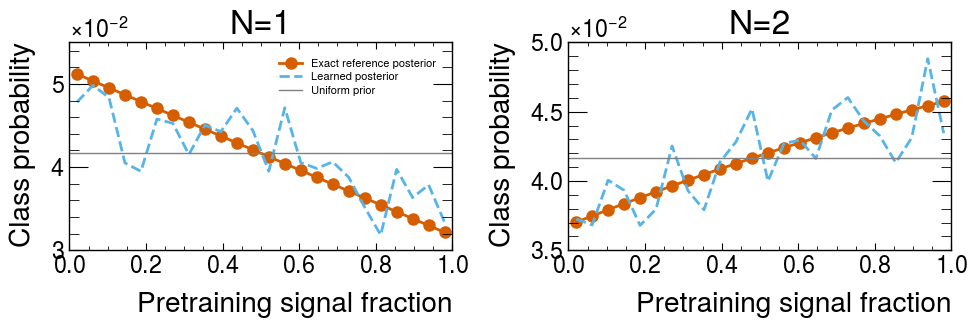

In [7]:
def reference_pair_check():
    rows = np.flatnonzero(pair_val['domain'] == 0)
    x = pair_val['x'][rows]
    n = pair_val['n'][rows]
    q = model_values(x.reshape(-1, len(FEATURES)))[0].reshape(len(rows), 2)
    ref = BANKS['validation']['reference']
    # pS_j/pB_j = ratio_scale*q_j on this common reference bank.
    ratio_scale = ref['signal']['p'][0] / ref['background']['p'][0] / ref['signal']['q'][0]
    exact = ep.reference_fraction_posterior(q, n, FRACTIONS, ratio_scale)
    with torch.no_grad():
        logits = posterior(torch.as_tensor(x, device=DEVICE),
            torch.as_tensor(n, device=DEVICE),
            torch.zeros(len(rows), dtype=torch.long, device=DEVICE))
        log_neural = logits.log_softmax(-1).cpu().numpy().astype(float)
    return dict(rows=rows, exact=exact, log_neural=log_neural)

oracle = cached_arrays('reference_pair_oracle', reference_pair_check, folder=HEAD_OUT)
oracle_rows, exact = oracle['rows'], oracle['exact']
log_exact, log_neural = np.log(exact), oracle['log_neural']
label = pair_val['label'][oracle_rows]
entropy = -np.sum(exact * log_exact, axis=1)
soft_ce = -np.sum(exact * log_neural, axis=1)
oracle_table = pd.DataFrame([dict(N=n, sets=int((pair_val['n'][oracle_rows]==n).sum()),
    prior_cross_entropy=np.log(N_FRACTIONS),
    neural_label_ce=-log_neural[pair_val['n'][oracle_rows]==n, label[pair_val['n'][oracle_rows]==n]].mean(),
    exact_label_ce=-log_exact[pair_val['n'][oracle_rows]==n, label[pair_val['n'][oracle_rows]==n]].mean(),
    exact_posterior_entropy=entropy[pair_val['n'][oracle_rows]==n].mean(),
    neural_soft_ce=soft_ce[pair_val['n'][oracle_rows]==n].mean(),
    mean_kl=(soft_ce-entropy)[pair_val['n'][oracle_rows]==n].mean()) for n in (1,2)])
display(oracle_table)
oracle_table.to_csv(HEAD_OUT / 'pair_oracle.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, n in zip(axes, (1, 2)):
    i = np.flatnonzero(pair_val['n'][oracle_rows] == n)[0]
    ax.plot(FRACTIONS, exact[i], 'o-', label='Exact reference posterior')
    ax.plot(FRACTIONS, np.exp(log_neural[i]), '--', label='Learned posterior')
    ax.axhline(1/N_FRACTIONS, color='grey', lw=1, label='Uniform prior')
    ax.set(xlabel='Pretraining signal fraction', ylabel='Class probability', title=f'N={n}')
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(HEAD_OUT / 'pair_oracle.png', dpi=150)
plt.show()


### Freeze and cache the event embeddings

The encoder now stays fixed. Encoding each stored event once costs work proportional to the bank size. We then form each experiment by summing its event embeddings and retaining $N$. All sums and means below use float64 so the small fluctuations of a large event set are not lost during aggregation.

The resulting head training no longer backpropagates through thousands of events per experiment. Applying the trained method to a new observed experiment still requires one pass over all its events. An empty experiment has $N=0$ and a zero mean embedding by convention.


The small cache/permutation comparison below is only an absolute diagnostic. A batch-size-dependent encoder difference must be compared with full-experiment fluctuations; the later numerical check does that and measures its effect on inference. We do not loosen a tolerance and interpret that as evidence of negligible inference error.


In [8]:
encoding_start = time.perf_counter()
for split, sources in BANKS.items():
    for source, processes in sources.items():
        if source == 'reference':
            encoded = cached_arrays(f'{split}_reference_embedding', lambda: dict(
                e=ep.encode_events(encoder, processes['signal']['x'], device=DEVICE)))['e']
            for bank in processes.values():
                bank['e'] = encoded
        else:
            for process, bank in processes.items():
                bank['e'] = cached_arrays(f'{split}_simulator_{process}_embedding',
                    lambda: dict(e=ep.encode_events(encoder, bank['x'], device=DEVICE)))['e']
ENCODING_SECONDS = time.perf_counter() - encoding_start
print(f'Event encoding/cache loading: {ENCODING_SECONDS:.1f} s')

# A small direct check: cached aggregation equals encoding the same raw events.
check_x = BANKS['audit']['simulator']['signal']['x'][:200]
check_e = BANKS['audit']['simulator']['signal']['e'][:200]
direct = ep.encode_events(encoder, check_x[::-1].copy(), device=DEVICE).mean(0, dtype=float)
cached = check_e.mean(0, dtype=float)
print('Permutation/cache maximum difference:', np.max(np.abs(direct-cached)))
# A full-experiment check in standardized units appears after head training.


Event encoding/cache loading: 62.4 s
Permutation/cache maximum difference: 6.0187894850969106e-05


## 2. Learn the response map with an amortized population fit

The response map is the reference-model parameter that maximizes the **expected** reference log likelihood for simulator experiments:

$$g(\mu)=\arg\max_{\nu\geq0}\mathbb E_{D\sim P_{\rm sim}^{\mu}}[\ell_H(\nu;D)].$$

It is not the mean finite-experiment estimator $\mathbb E[\hat\nu]$. For our additive likelihood, the expectation separates into signal and background event expectations. We train a small network $g_\rho$ directly by minimizing

$$\mathcal L_g=\mathbb E_\mu\left[\lambda_S g_\rho(\mu)
-\mu\lambda_S\mathbb E_{S,\rm sim}\log(1+g_\rho(\mu)q)
-\lambda_B\mathbb E_{B,\rm sim}\log(1+g_\rho(\mu)q)\right].$$

Uniformly sampled $\mu$ values and event minibatches give stochastic gradients. We differentiate only through $g_\rho$, not through the simulator. No grid of fitted response targets is used for training. Independent validation-bank objective values select the checkpoint; the audit bank is used only afterward.

There is one small variance-reduction step: write $\log(1+\nu q)=\nu q+[\log(1+\nu q)-\nu q]$. The full bank gives the linear term's mean exactly; minibatches estimate only the bracketed remainder. This is the same empirical population objective with less noise from the dominant background. Likelihood arithmetic uses float64.

The network enforces nonnegative output but does not force $g(0)=0$. An ideal internally consistent reference model has the identity response $g_H(\nu)=\nu$; we check this numerically below. Unlike $g$, a neural estimator trained on individual experiments learns a finite-sample fitting operation. These are different learning problems.


In [9]:
torch.manual_seed(SEED+4)
response = ep.ResponseNet(mu_max=MU_MAX, width=32)
sim_train = BANKS['train']['simulator']
sim_val = BANKS['validation']['simulator']
response_history = cached_model('response', response, lambda: ep.train_response(
    response, sim_train['signal']['q'], sim_train['background']['q'], LAM_S, LAM_B,
    val_q_sig=sim_val['signal']['q'], val_q_bkg=sim_val['background']['q'],
    mu_max=MU_MAX, epochs=SIZES['response_epochs'], steps_per_epoch=8,
    mu_batch=32, event_batch=4096, lr=1e-3, patience=25, seed=SEED+4, device=DEVICE))

def response_value(mu):
    with torch.no_grad():
        values = response(torch.as_tensor(np.asarray(mu), dtype=torch.float32, device=DEVICE))
    return values.cpu().numpy().astype(float)

print('Learned g(0), g(1), g(3):', response_value([0, 1, 3]))


Learned g(0), g(1), g(3): [0.00804374 1.00904942 3.01186252]


### Validate the population fit against direct unbinned score roots

For a chosen bank, the exact scalar score equation is

$$-\lambda_S+\mu\lambda_S\left\langle\frac{q}{1+\nu q}\right\rangle_S
+\lambda_B\left\langle\frac{q}{1+\nu q}\right\rangle_B=0.$$

If its value at zero is nonpositive, the constrained optimum is zero. Otherwise it has a unique positive root when the model is identifiable. We evaluate direct roots only at validation points, after training the response network.

We compare the network with roots on both its training bank and an independent audit bank. Their difference exposes finite-bank integration error. The curvature scale $\sigma_A=I^{-1/2}$ is a useful unit for the response error, not a claim about the simulator's estimator variance under misspecification. The objective gap is $2[\bar\ell(g_{\rm root})-\bar\ell(g_\rho)]$.


,mu,learned,audit_root,train_root,reference_root,sigma_A,error_over_sigma,bank_shift_over_sigma,objective_gap,score_at_learned
0,0.00,0.008042,0.000000,0.000000,0.000000,0.562519,0.014297,0.000000,0.002371,-0.160131
1,0.25,0.258265,0.210252,0.234727,0.167924,0.562892,0.085298,0.043481,0.007274,-0.151476
2,0.50,0.508507,0.463102,0.487673,0.417864,0.563458,0.080583,0.043608,0.006492,-0.142963
3,0.75,0.758769,0.715938,0.740603,0.667805,0.564021,0.075938,0.043730,0.005765,-0.134590
4,1.00,1.009049,0.968761,0.993516,0.917747,0.564583,0.071359,0.043846,0.005091,-0.126353
5,1.25,1.259347,1.221569,1.246412,1.167689,0.565142,0.066846,0.043958,0.004467,-0.118246
6,1.50,1.509661,1.474364,1.499291,1.417631,0.565699,0.062396,0.044065,0.003893,-0.110269
7,1.75,1.759992,1.727145,1.752155,1.667574,0.566254,0.058008,0.044167,0.003364,-0.102415
8,2.00,2.010339,1.979913,2.005003,1.917517,0.566807,0.053679,0.044264,0.002881,-0.094682
9,2.25,2.260700,2.232668,2.257835,2.167461,0.567358,0.049408,0.044357,0.002441,-0.087065


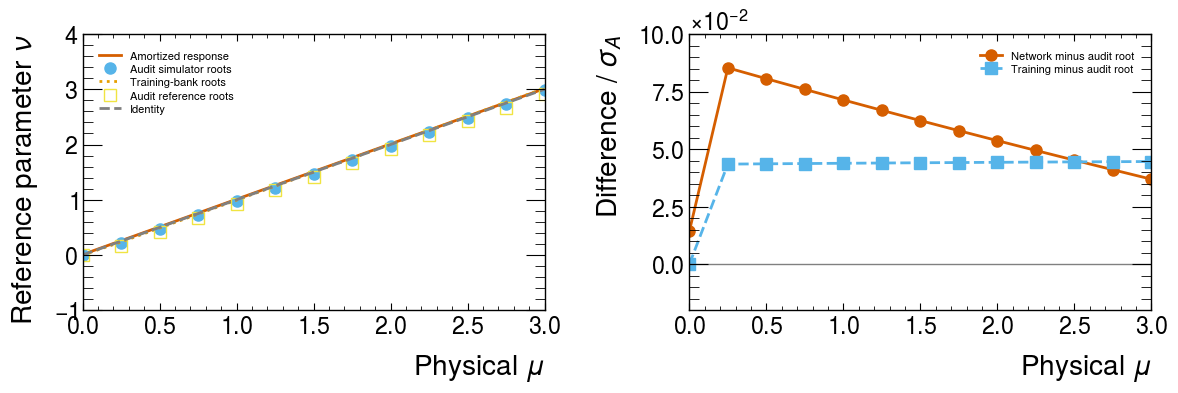

In [10]:
def bank_mean(bank, values):
    return values.mean() if bank['p'] is None else np.dot(bank['p'], values)

def population_score(nu, mu, processes):
    s, b = processes['signal'], processes['background']
    return (-LAM_S + mu * LAM_S * bank_mean(s, s['q'] / (1 + nu*s['q']))
            + LAM_B * bank_mean(b, b['q'] / (1 + nu*b['q'])))

def population_fit(mu, processes):
    if population_score(0, mu, processes) <= 0:
        return 0.0
    upper = max(1.0, mu)
    while population_score(upper, mu, processes) > 0:
        upper *= 2
    return brentq(lambda nu: population_score(nu, mu, processes), 0, upper)

def population_loglik(nu, mu, processes):
    s, b = processes['signal'], processes['background']
    return (-nu*LAM_S + mu*LAM_S*bank_mean(s, np.log1p(nu*s['q']))
            + LAM_B*bank_mean(b, np.log1p(nu*b['q'])))

def population_information(nu, mu, processes):
    s, b = processes['signal'], processes['background']
    return (mu*LAM_S*bank_mean(s, (s['q']/(1+nu*s['q']))**2)
            + LAM_B*bank_mean(b, (b['q']/(1+nu*b['q']))**2))

MU_ANCHORS = np.linspace(0, MU_MAX, 13)
response_rows = []
for mu in MU_ANCHORS:
    learned = float(response_value([mu])[0])
    audit = BANKS['audit']['simulator']
    root = population_fit(mu, audit)
    train_root = population_fit(mu, BANKS['train']['simulator'])
    sigma = population_information(root, mu, audit)**-0.5
    response_rows.append(dict(mu=mu, learned=learned, audit_root=root,
        train_root=train_root, reference_root=population_fit(mu, BANKS['audit']['reference']),
        sigma_A=sigma, error_over_sigma=(learned-root)/sigma,
        bank_shift_over_sigma=(train_root-root)/sigma,
        objective_gap=2*(population_loglik(root, mu, audit)-population_loglik(learned, mu, audit)),
        score_at_learned=population_score(learned, mu, audit)))
response_table = pd.DataFrame(response_rows)
response_table.to_csv(HEAD_OUT / 'response_validation.csv', index=False)
display(response_table)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(MU_ANCHORS, response_table.learned, label='Amortized response')
axes[0].plot(MU_ANCHORS, response_table.audit_root, 'o', label='Audit simulator roots')
axes[0].plot(MU_ANCHORS, response_table.train_root, ':', label='Training-bank roots')
axes[0].plot(MU_ANCHORS, response_table.reference_root, 's', fillstyle='none', label='Audit reference roots')
axes[0].plot(MU_ANCHORS, MU_ANCHORS, '--', color='grey', label='Identity')
axes[0].set(xlabel=r'Physical $\mu$', ylabel=r'Reference parameter $\nu$')
axes[0].legend(fontsize=8)
axes[1].plot(MU_ANCHORS, response_table.error_over_sigma, 'o-', label='Network minus audit root')
axes[1].plot(MU_ANCHORS, response_table.bank_shift_over_sigma, 's--', label='Training minus audit root')
axes[1].axhline(0, color='grey', lw=1)
axes[1].set(xlabel=r'Physical $\mu$', ylabel=r'Difference / $\sigma_A$')
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(HEAD_OUT / 'response_validation.png', dpi=150)
plt.show()
assert response_table.learned.max() < NU_QUERY_MAX, 'Increase NU_QUERY_MAX and rerun for this deformation.'


### Diagnose the reference self-response shift

Reference-bank toys normalize signal and background sampling probabilities separately, whereas the likelihood keeps its original normalization sample. Their small relative normalization difference can visibly shift a high-statistics population fit.

For each independent reference bank, we inspect nested prefixes. If $\bar r_S$ and $\bar r_B$ are the mean frozen ratios on that prefix, then its own process-normalized likelihood ratio would be $q_{\rm same}=q\,\bar r_B/\bar r_S$. The population response computed with this diagnostic ratio closes exactly to the injected value on the same finite bank. Comparing it with the frozen likelihood identifies normalization inconsistency without changing the model used for training or inference.

We reconstruct the original per-event ratios from the cached weights and their stored means. No new simulation is needed. Agreement across increasingly large independent banks tests integration stability; a common offset can also originate in the fixed normalization sample. This check does not replace a future larger-normalization-sample study.


In [11]:
normalization_rows = []
for split in ['train', 'validation', 'audit']:
    ref = BANKS[split]['reference']
    total = len(ref['signal']['q'])
    s = ref['signal']['p'] * total * REFERENCE_MEANS[split][0]
    b = ref['background']['p'] * total * REFERENCE_MEANS[split][1]
    prefixes = sorted(set([max(2, total//4), max(2, total//2), total]))
    for n in prefixes:
        q = ref['signal']['q'][:n]
        ps, pb = s[:n]/s[:n].sum(), b[:n]/b[:n].sum()
        mean_s, mean_b = s[:n].mean(), b[:n].mean()
        frozen_root = ep.exact_response(q, q, 1., LAM_S, LAM_B, ps, pb)
        same_q = q * mean_b/mean_s
        same_root = ep.exact_response(same_q, same_q, 1., LAM_S, LAM_B, ps, pb)
        normalization_rows.append(dict(split=split, events=n, mean_signal=mean_s,
            mean_background=mean_b, mean_signal_se=s[:n].std(ddof=1)/np.sqrt(n),
            mean_background_se=b[:n].std(ddof=1)/np.sqrt(n),
            frozen_response_at_one=frozen_root, same_bank_response_at_one=same_root))
normalization_table = pd.DataFrame(normalization_rows)
display(normalization_table)
normalization_table.to_csv(HEAD_OUT / 'reference_normalization.csv', index=False)


,split,events,mean_signal,mean_background,mean_signal_se,mean_background_se,frozen_response_at_one,same_bank_response_at_one
0,train,500000,0.999688,1.000067,0.000275,0.000325,0.926401,1.0
1,train,1000000,0.999600,1.000175,0.000195,0.000231,0.888366,1.0
2,train,2000000,0.999740,1.000291,0.000138,0.000173,0.893204,1.0
3,validation,250000,0.999452,1.000772,0.000389,0.000479,0.743832,1.0
4,validation,500000,0.999317,1.000540,0.000275,0.000331,0.762484,1.0
5,validation,1000000,0.999731,1.000299,0.000195,0.000234,0.889870,1.0
6,audit,500000,0.999745,1.000369,0.000275,0.000336,0.878932,1.0
7,audit,1000000,0.999963,1.000094,0.000195,0.000235,0.974620,1.0
8,audit,2000000,0.999774,1.000198,0.000138,0.000165,0.917747,1.0


### Relative normalization: what is uncertain?

The signal and background ratios are evaluated on the **same** reference events, so their Monte Carlo errors are correlated. Separate error bars on their means do not tell us the uncertainty in their relative normalization. For each cached reference bank we instead examine

$$R=\frac{\bar s}{\bar b}, \qquad
\widehat{\mathrm{SE}}(R)=\frac{\operatorname{sd}(s_i-Rb_i)}{\bar b\sqrt{M}}.$$

This is the paired delta-method standard error for a bank of $M$ independent reference events. The subtraction inside the standard deviation preserves the signal/background covariance. Here $s_i$ is the already deformed signal ratio and $b_i$ is the background ratio; we reconstruct their values from the cached sampling weights and means.

The table reports the departure $R-1$, its estimated standard error, and their ratio. These errors are **conditional on the frozen learned models and the normalization constants already used by the likelihood**. Independent banks measure the precision of this check. They do not directly measure the uncertainty of the original normalization sample, whose error is shared by all three banks. A common displacement from one can therefore survive as the diagnostic banks become larger. To measure variability from normalization itself we would need independent normalization replicas; that is a separate experiment.

We also divide each bank into four disjoint blocks to see how stable the result is within that bank. Blocks from one bank use the same frozen normalization. The existing nested-prefix results overlap and should not be treated as independent measurements.

The earlier same-bank normalization check returns an identity response by construction. It verifies the algebra, but does not establish that the Monte Carlo normalization error has disappeared. **These diagnostics leave `NORMALIZATION`, every stored event ratio, and all trained models unchanged.**

In [ ]:
def paired_normalization_summary(s, b):
    ratio = s.mean() / b.mean()
    influence = (s - ratio*b) / b.mean()
    se = influence.std(ddof=1) / np.sqrt(len(s))
    return dict(events=len(s), ratio_signal_background=ratio,
                ratio_minus_one=ratio-1, paired_se=se,
                displacement_over_se=(ratio-1)/se)

relative_normalization_rows, normalization_block_rows = [], []
for split in ['train', 'validation', 'audit']:
    reference = BANKS[split]['reference']
    n = len(reference['signal']['q'])
    s = reference['signal']['p'] * n * REFERENCE_MEANS[split][0]
    b = reference['background']['p'] * n * REFERENCE_MEANS[split][1]
    relative_normalization_rows.append(dict(
        split=split, **paired_normalization_summary(s, b)))
    for block, (s_block, b_block) in enumerate(zip(np.array_split(s, 4), np.array_split(b, 4))):
        normalization_block_rows.append(dict(
            split=split, block=block+1,
            **paired_normalization_summary(s_block, b_block)))

relative_normalization = pd.DataFrame(relative_normalization_rows)
normalization_blocks = pd.DataFrame(normalization_block_rows)
display(relative_normalization)
display(normalization_blocks)
relative_normalization.to_csv(DIAG_OUT / 'relative_normalization_uncertainty.csv', index=False)
normalization_blocks.to_csv(DIAG_OUT / 'relative_normalization_blocks.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(np.arange(3), relative_normalization.ratio_minus_one,
                 yerr=relative_normalization.paired_se, fmt='o', capsize=4)
axes[0].set_xticks(np.arange(3), relative_normalization.split)
axes[0].set(title='Full banks: paired standard errors', ylabel=r'$R-1$')
for split, group in normalization_blocks.groupby('split', sort=False):
    axes[1].errorbar(group.block, group.ratio_minus_one, yerr=group.paired_se,
                     fmt='o-', capsize=3, label=split)
axes[1].set(xlabel='Disjoint block', ylabel=r'$R-1$', title='Four blocks within each bank')
axes[1].set_xticks([1, 2, 3, 4])
axes[1].legend()
for axis in axes:
    axis.axhline(0, color='grey', lw=1)
fig.tight_layout()
fig.savefig(DIAG_OUT / 'relative_normalization_uncertainty.png', dpi=150)
plt.show()

### Separate response-network error from event-bank variation

The response network approximates the population optimum $g(\mu)$, not the mean fitted estimator from finite experiments. The earlier response check compared its prediction with numerical score roots from the training and audit banks. We now include the **validation-bank root**, since this bank was used to select the response network during training.

For each physical parameter $\mu$, compare the learned response with each of the three numerical roots. We express all differences using the same scale $\sigma_A$ from the audit-bank likelihood curvature. This is a convenient scale for the displacement of a fitted parameter; it is not a confidence interval for the population root or an estimate of its Monte Carlo error.

If the learned response agrees with the training and validation roots while those roots differ from the audit root, increasing the event-bank size is a more relevant next test than increasing the response network. If it misses all three roots similarly, its approximation or optimization deserves attention. These comparisons are diagnostic: the validation bank participates in model selection, and the audit bank becomes a development check once we use its results to choose improvements. The final coverage assessment will need fresh independent experiments.

In [ ]:
response_bank_table = response_table[['mu', 'learned', 'train_root', 'audit_root', 'sigma_A']].copy()
response_bank_table['validation_root'] = [
    population_fit(mu, BANKS['validation']['simulator'])
    for mu in response_bank_table.mu]
for split in ['train', 'validation', 'audit']:
    response_bank_table[f'learned_minus_{split}_over_sigma'] = (
        response_bank_table.learned - response_bank_table[f'{split}_root']
    ) / response_bank_table.sigma_A
for split in ['train', 'validation']:
    response_bank_table[f'{split}_minus_audit_over_sigma'] = (
        response_bank_table[f'{split}_root'] - response_bank_table.audit_root
    ) / response_bank_table.sigma_A
display(response_bank_table)
response_bank_table.to_csv(DIAG_OUT / 'response_three_bank_comparison.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for split in ['train', 'validation', 'audit']:
    axes[0].plot(response_bank_table.mu,
                 response_bank_table[f'learned_minus_{split}_over_sigma'],
                 'o-', label=f'Learned minus {split}')
for split in ['train', 'validation']:
    axes[1].plot(response_bank_table.mu,
                 response_bank_table[f'{split}_minus_audit_over_sigma'],
                 'o-', label=f'{split.capitalize()} minus audit')
for axis in axes:
    axis.axhline(0, color='grey', lw=1)
    axis.set(xlabel=r'Physical $\mu$', ylabel=r'Difference / $\sigma_A$')
    axis.legend(fontsize=9)
axes[0].set_title('Learned response versus each population root')
axes[1].set_title('Variation between event banks')
fig.tight_layout()
fig.savefig(DIAG_OUT / 'response_three_bank_comparison.png', dpi=150)
plt.show()

## 3. Generate full experiments and exact teacher labels

For each physical design point $\mu$, simulator toys use signal mean $\mu\lambda_S$; reference toys use signal mean $g_\rho(\mu)\lambda_S$. Both use background mean $\lambda_B$. The Poisson counts fluctuate independently.

We fit **the same** reference likelihood to both sources and evaluate

$$\hat\nu(D)=\arg\max_{\nu\geq0}\ell_H(\nu;D),\qquad
T_\nu(D)=2[\ell_H(\hat\nu;D)-\ell_H(\nu;D)].$$

Each row stores the embedding, count, teacher estimator and several queried statistic values. Queries include $g_\rho(\mu)$, zero, the exact minimum, and random values in the configured query range. The validation and audit use fresh continuous queries, so they test interpolation rather than memorization of a grid. Whole experiments stay in a single split.

We generate one experiment at a time and discard its event indices after summation and fitting. This avoids storing a giant padded tensor. Nevertheless, drawing and labeling full experiments is still real computation. The acceleration comes afterward, when the cached embeddings are reused for head training and inference. At inference time, neither head receives the source or true $\mu$.


In [12]:
def draw_experiment(processes, generating_nu, rng):
    total_embedding = np.zeros(EMBED_DIM, dtype=float)
    q_parts = []
    counts = [rng.poisson(generating_nu * LAM_S), rng.poisson(LAM_B)]
    for process, count in zip(['signal', 'background'], counts):
        bank = processes[process]
        indices = draw_indices(bank, count, rng)
        total_embedding += bank['e'][indices].sum(axis=0, dtype=float)
        q_parts.append(bank['q'][indices])
    n = sum(counts)
    z = np.r_[float(n), total_embedding / n if n else total_embedding]
    return z, np.concatenate(q_parts)

def make_toy_table(split, count_per_source, seed):
    rng = np.random.default_rng(seed)
    records = []
    started = time.perf_counter()
    for domain, source in enumerate(DOMAINS):
        mu = rng.uniform(0, MU_MAX, count_per_source)
        # Deliberate endpoint examples, in addition to the continuous design.
        mu[:max(1, count_per_source//10)] = 0
        mu[-max(1, count_per_source//10):] = MU_MAX
        mapped = response_value(mu)
        for i in range(count_per_source):
            generating_nu = mapped[i] if source == 'reference' else mu[i]
            z, q = draw_experiment(BANKS[split][source], generating_nu, rng)
            fitted = ep.exact_fit(q, LAM_S)
            queries = rng.uniform(0, NU_QUERY_MAX, N_QUERY)
            queries[:3] = [mapped[i], 0, fitted]
            statistic = ep.exact_statistic(q, queries, LAM_S, nu_hat=fitted)
            records.append((z, fitted, queries, statistic, mu[i], domain))
            if (i+1) % max(1, count_per_source//5) == 0:
                print(f'{split}: {source} {i+1}/{count_per_source}')
    names = ['z', 'nu_hat', 'nu', 't', 'mu', 'domain']
    result = {name: np.asarray([row[j] for row in records]) for j, name in enumerate(names)}
    result['generation_seconds'] = np.asarray(time.perf_counter()-started)
    return result

TABLES = {}
for k, split in enumerate(['train', 'validation', 'audit']):
    TABLES[split] = cached_arrays(f'{split}_toys', lambda: make_toy_table(
        split, SIZES[f'toys_{split}'], SEED+500+k))
    table = TABLES[split]
    print(split, 'experiments:', len(table['z']),
          'mean N:', table['z'][:, 0].mean(),
          'generation seconds:', float(table['generation_seconds']),
          'fraction of MLEs above query range:', np.mean(table['nu_hat'] > NU_QUERY_MAX))
    assert np.min(table['t']) >= -1e-7
    assert np.max(np.abs(table['t'][:, 2])) < 1e-7


train experiments: 3000 mean N: 153746.778 generation seconds: 278.80216713900154 fraction of MLEs above query range: 0.0
validation experiments: 600 mean N: 153707.675 generation seconds: 45.51139479399899 fraction of MLEs above query range: 0.0
audit experiments: 600 mean N: 153726.36333333334 generation seconds: 54.98512550000123 fraction of MLEs above query range: 0.0


### Train two flexible statistic heads on the same cached experiments

We compare two targets, using identical train/validation splits and network sizes:

* **Signed root:** $r_\nu=\operatorname{sign}(\nu-\hat\nu_{\rm teacher})\sqrt{T_\nu}$. The output is unrestricted and we set $\widehat T_\nu=\widehat r_\nu^2$. Its mean-squared loss is smoother near a single interior likelihood minimum than regression of the unsigned root.
* **Direct statistic:** predict nonnegative $T_\nu$ with a softplus output and use smooth-L1 loss (quadratic for absolute error below one, linear above one). This retains a flexible comparison without allowing the largest tail errors to dominate every update.

Both estimator heads use a ReLU output so exact zeros are possible, with positive initial bias to start training away from a completely inactive output. Their loss is mean-squared estimator error in training-set scale units. Each model still receives only the observed embedding/count and query $\nu$, never the injected parameter or source label.

Neither model assumes a quadratic, convex or single-minimum statistic. The signed-root transformation's smoothness advantage is local to a regular minimum and is not guaranteed with degeneracies; this is why we retain the direct head. The two heads are approximations and their estimator/statistic minima need not be exactly consistent. The exact likelihood teacher in this particular example still exploits the yield-linear model's concavity; an interference example would need a more general teacher fit.

We allow 400 epochs, reduce the learning rate on a validation plateau, and restore the best validation checkpoint. Estimator and statistic losses are recorded separately. The two statistic losses have different units and should not be compared directly; validation RMSE in $T$ is common to both. The original unsigned-root checkpoint is evaluated when available, without retraining it.


signed_root epoch   1: val=9.4139, estimator=0.51909, statistic=8.8948, lr=0.001
signed_root epoch  20: val=0.093786, estimator=0.016047, statistic=0.077739, lr=0.001
signed_root epoch  40: val=0.097395, estimator=0.015237, statistic=0.082159, lr=0.001
signed_root epoch  60: val=0.08275, estimator=0.013986, statistic=0.068764, lr=0.001
signed_root epoch  80: val=0.077751, estimator=0.013545, statistic=0.064206, lr=0.001
signed_root epoch 100: val=0.071843, estimator=0.013326, statistic=0.058516, lr=0.001
signed_root epoch 120: val=0.070314, estimator=0.013079, statistic=0.057235, lr=0.001
signed_root epoch 140: val=0.079655, estimator=0.013901, statistic=0.065754, lr=0.001
signed_root epoch 160: val=0.068895, estimator=0.013029, statistic=0.055865, lr=0.0003
signed_root epoch 180: val=0.076943, estimator=0.013653, statistic=0.063289, lr=0.0003
signed_root epoch 200: val=0.070245, estimator=0.013148, statistic=0.057097, lr=9e-05
signed_root epoch 220: val=0.070223, estimator=0.01313, st

,model,estimator_bias,estimator_rmse,statistic_bias,statistic_rmse,scan_statistic_rmse,mean_T_at_teacher_minimum
0,signed_root,-0.017934,0.125478,0.014898,0.475370,1.680093,0.059854
1,direct,-0.012217,0.128621,0.056821,0.484267,2.009769,0.186933
2,original_unsigned_root,0.002694,0.134616,-0.158683,0.698446,2.065825,0.324826


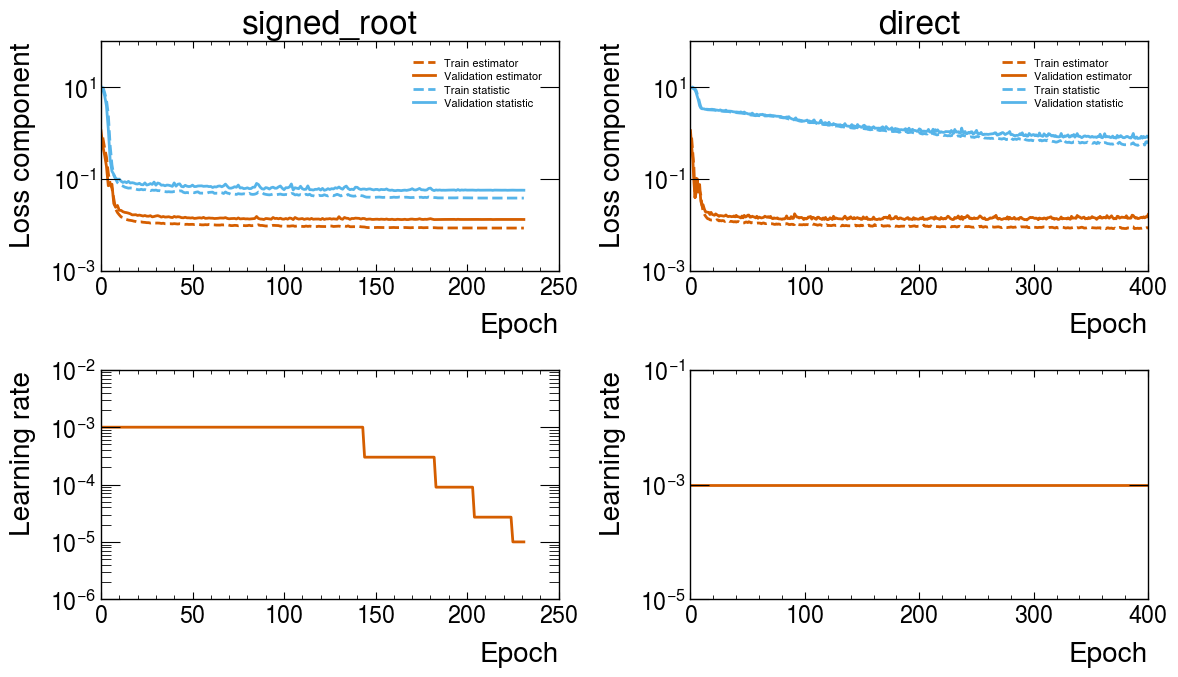

,model,source,estimator_bias,estimator_rmse,statistic_bias,statistic_rmse,scan_statistic_rmse,mean_T_at_teacher_minimum
0,signed_root,reference,-0.071553,0.141481,0.036450,0.436510,1.811952,0.069576
1,signed_root,simulator,-0.042260,0.124767,0.043687,0.421167,1.746112,0.056113
2,direct,reference,-0.065269,0.143262,0.075359,0.495480,1.925698,0.191116
3,direct,simulator,-0.028447,0.128241,0.076579,0.479686,1.944419,0.177543
4,original_unsigned_root,reference,-0.059281,0.151536,-0.112663,0.592519,2.282863,0.313815
5,original_unsigned_root,simulator,-0.035143,0.134105,-0.127596,0.589700,2.078712,0.320570


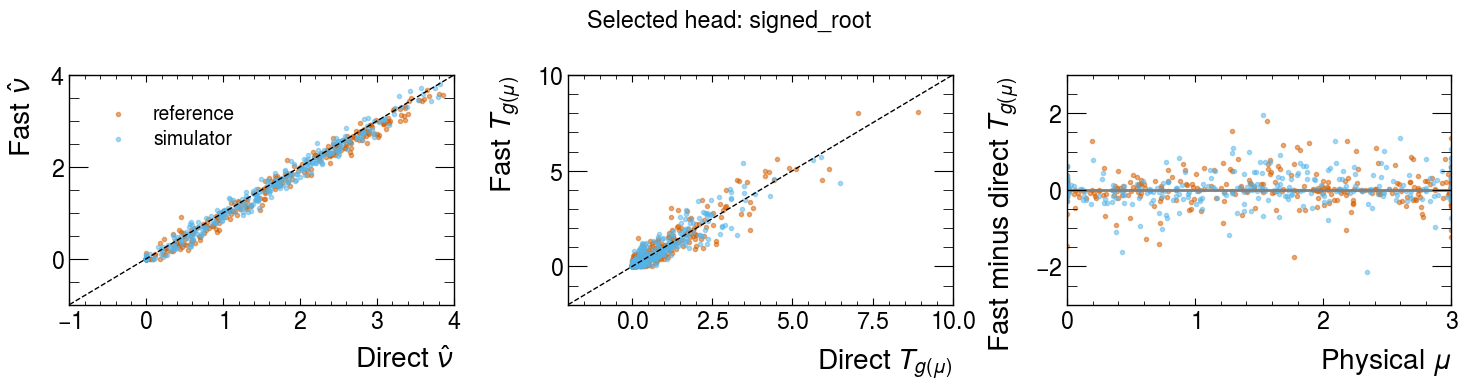

In [13]:
def fit_refined_head(name, train, validation, mode, seed):
    torch.manual_seed(seed)
    model = ep.RefinedHeads(train['z'].shape[1], width=HEAD_SETTINGS['width'], mode=mode)
    history = cached_model(name, model, lambda: ep.train_refined_heads(
        model, train, validation, epochs=HEAD_SETTINGS['epochs'],
        batch_size=HEAD_SETTINGS['batch_size'], lr=HEAD_SETTINGS['lr'],
        patience=HEAD_SETTINGS['patience'], lr_patience=HEAD_SETTINGS['lr_patience'],
        seed=seed, device=DEVICE, lr_factor=HEAD_SETTINGS['lr_factor'],
        min_lr=HEAD_SETTINGS['min_lr']), folder=HEAD_OUT)
    return model, history

MODELS, HISTORIES = {}, {}
for mode in HEAD_SETTINGS['modes']:
    MODELS[mode], HISTORIES[mode] = fit_refined_head(f'heads_{mode}',
        TABLES['train'], TABLES['validation'], mode, HEAD_SETTINGS['seed'])

legacy_path = DATA_OUT / 'heads.pt'
if legacy_path.exists():
    legacy = ep.FastHeads(EMBED_DIM+1, width=96)
    legacy.load_state_dict(torch.load(legacy_path, map_location='cpu', weights_only=True)['state_dict'])
    MODELS['original_unsigned_root'] = legacy.to(DEVICE).eval()

def prediction_metrics(table, predicted_hat, predicted_t):
    dh = predicted_hat-table['nu_hat']
    dt = predicted_t-table['t']
    return dict(estimator_bias=dh.mean(), estimator_rmse=np.sqrt(np.mean(dh**2)),
        statistic_bias=dt[:,0].mean(), statistic_rmse=np.sqrt(np.mean(dt[:,0]**2)),
        scan_statistic_rmse=np.sqrt(np.mean(dt[:,3:]**2)),
        mean_T_at_teacher_minimum=predicted_t[:,2].mean())

validation_rows = []
for name, model in MODELS.items():
    prediction = ep.predict_heads(model, TABLES['validation']['z'], TABLES['validation']['nu'], device=DEVICE)
    validation_rows.append(dict(model=name, **prediction_metrics(TABLES['validation'], *prediction)))
validation_comparison = pd.DataFrame(validation_rows)
display(validation_comparison)
validation_comparison.to_csv(HEAD_OUT / 'validation_comparison.csv', index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for col, mode in enumerate(HEAD_SETTINGS['modes']):
    history = pd.DataFrame(HISTORIES[mode])
    for component, color in [('estimator', 'C0'), ('statistic', 'C1')]:
        axes[0,col].plot(history.epoch, history[f'train_{component}'], color=color, ls='--', label=f'Train {component}')
        axes[0,col].plot(history.epoch, history[f'val_{component}'], color=color, label=f'Validation {component}')
    axes[0,col].set(title=mode, xlabel='Epoch', ylabel='Loss component', yscale='log')
    axes[0,col].legend(fontsize=8)
    axes[1,col].plot(history.epoch, history.lr)
    axes[1,col].set(xlabel='Epoch', ylabel='Learning rate', yscale='log')
fig.tight_layout()
fig.savefig(HEAD_OUT / 'head_training.png', dpi=150)
plt.show()

# This audit was inspected in the first run: use it for development comparison.
audit = TABLES['audit']
PREDICTIONS = {name: ep.predict_heads(model, audit['z'], audit['nu'], device=DEVICE)
               for name, model in MODELS.items()}
metric_rows = []
for name, (estimated_hat, estimated_t) in PREDICTIONS.items():
    for d, domain in enumerate(DOMAINS):
        keep = audit['domain']==d
        subset = {key: audit[key][keep] for key in ['nu_hat', 't']}
        metric_rows.append(dict(model=name, source=domain,
            **prediction_metrics(subset, estimated_hat[keep], estimated_t[keep])))
metrics = pd.DataFrame(metric_rows)
display(metrics)
metrics.to_csv(HEAD_OUT / 'head_comparison.csv', index=False)
for name, (estimated_hat, estimated_t) in PREDICTIONS.items():
    np.savez(HEAD_OUT / f'audit_predictions_{name}.npz', nu_hat_fast=estimated_hat, t_fast=estimated_t)

heads = MODELS[SELECTED_HEAD]
hat_fast, t_fast = PREDICTIONS[SELECTED_HEAD]
hat_error, t_error = hat_fast-audit['nu_hat'], t_fast-audit['t']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for d, domain in enumerate(DOMAINS):
    keep = audit['domain']==d
    axes[0].scatter(audit['nu_hat'][keep], hat_fast[keep], s=9, alpha=.5, label=domain)
    axes[1].scatter(audit['t'][keep,0], t_fast[keep,0], s=9, alpha=.5, label=domain)
    axes[2].scatter(audit['mu'][keep], t_error[keep,0], s=9, alpha=.5, label=domain)
for ax in axes[:2]:
    low = min(ax.get_xlim()[0], ax.get_ylim()[0]); high = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([low, high], [low, high], 'k--', lw=1)
    ax.set_xlim(low, high); ax.set_ylim(low, high)
axes[0].set(xlabel=r'Direct $\hat\nu$', ylabel=r'Fast $\hat\nu$')
axes[1].set(xlabel=r'Direct $T_{g(\mu)}$', ylabel=r'Fast $T_{g(\mu)}$')
axes[2].set(xlabel=r'Physical $\mu$', ylabel=r'Fast minus direct $T_{g(\mu)}$')
axes[2].axhline(0, color='grey'); axes[0].legend()
fig.suptitle(f'Selected head: {SELECTED_HEAD}')
fig.tight_layout()
fig.savefig(HEAD_OUT / 'head_validation.png', dpi=150)
plt.show()


### Boundary, tail and interpolation diagnostics

Average regression error can hide the most relevant failures. We therefore inspect the error at the exact likelihood minimum, near several representative statistic levels, and on previously unseen query values. The levels below are merely diagnostic locations; **we are not using them as calibrated cutoffs**.

The exact boundary $\hat\nu=0$ can carry nonzero probability. Report its frequency and the head's behavior separately. A smooth nonnegative approximation need not reproduce this atom exactly, which matters for the later distribution model.


,model,source,region,entries,mean_abs_error,p95_abs_error
0,signed_root,reference,at exact minimum,300,0.069576,0.272779
1,signed_root,reference,0 <= T < 1,402,0.233501,0.790802
2,signed_root,reference,1 <= T < 2.71,260,0.481191,1.245377
3,signed_root,reference,2.71 <= T < 3.84,128,0.681736,1.738067
4,signed_root,reference,3.84 <= T < 8,318,0.937396,2.662994
5,signed_root,reference,8 <= T < inf,992,1.930406,4.947703
6,signed_root,simulator,at exact minimum,300,0.056113,0.219500
7,signed_root,simulator,0 <= T < 1,423,0.177088,0.603349
8,signed_root,simulator,1 <= T < 2.71,250,0.443803,1.150909
9,signed_root,simulator,2.71 <= T < 3.84,112,0.698904,1.836712


,model,source,toys,teacher_zero_fraction,predicted_zero_fraction,predicted_below_001_fraction,estimator_bias
0,signed_root,reference,67,0.492537,0.522388,0.537313,-0.021034
1,signed_root,simulator,64,0.421875,0.390625,0.390625,-0.016033
2,direct,reference,67,0.492537,0.522388,0.522388,-0.017289
3,direct,simulator,64,0.421875,0.421875,0.421875,-0.022381
4,original_unsigned_root,reference,67,0.492537,0.000000,0.059701,0.012339
5,original_unsigned_root,simulator,64,0.421875,0.000000,0.093750,0.007362


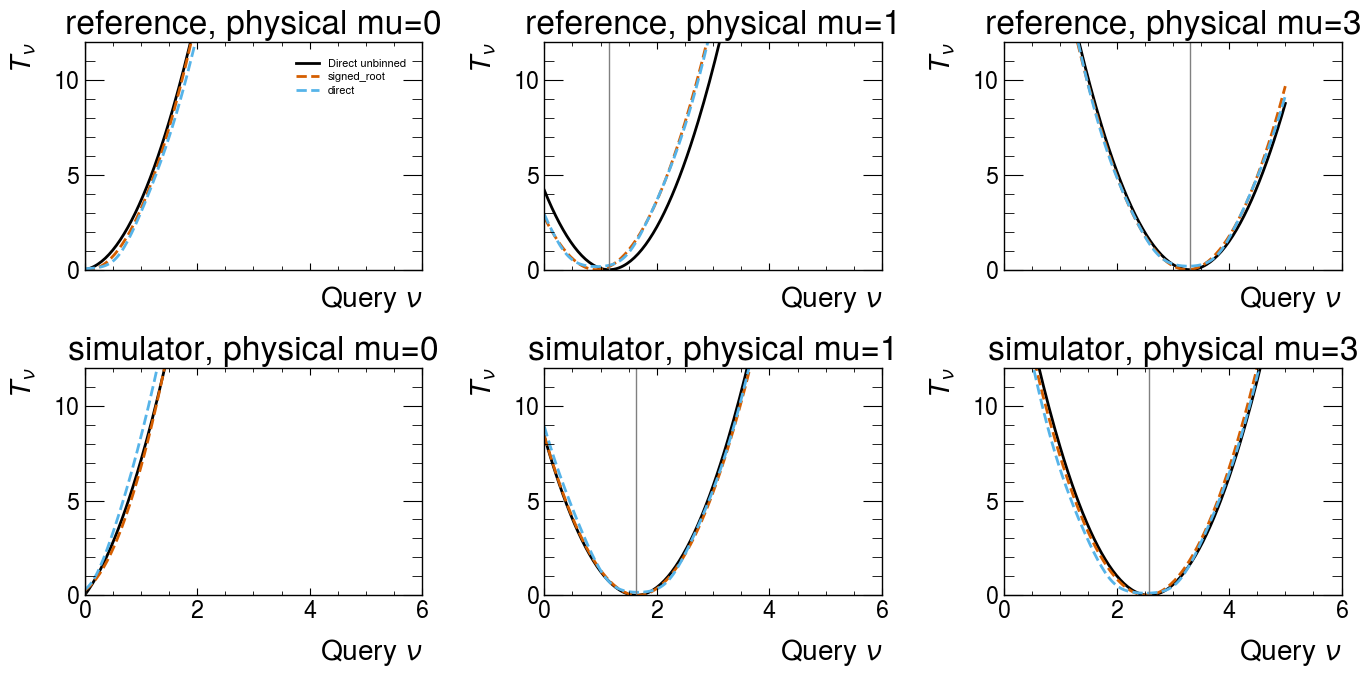

,model,source,mu,direct_mle,fast_mle,max_abs_scan_error
0,signed_root,reference,0.0,0.000000,0.000000,0.927791
1,direct,reference,0.0,0.000000,0.000000,3.497233
2,signed_root,reference,1.0,1.150670,0.925342,3.853178
3,direct,reference,1.0,1.150670,0.931613,4.685762
4,signed_root,reference,3.0,3.302044,3.233511,0.913770
5,direct,reference,3.0,3.302044,3.266439,7.800425
6,signed_root,simulator,0.0,0.000000,0.000000,5.576542
7,direct,simulator,0.0,0.000000,0.000000,5.694104
8,signed_root,simulator,1.0,1.633196,1.671401,1.645217
9,direct,simulator,1.0,1.633196,1.691137,0.871741


In [14]:
diagnostics, boundary_rows = [], []
for name, (estimated_hat, estimated_t) in PREDICTIONS.items():
    errors = estimated_t-audit['t']
    for d, domain in enumerate(DOMAINS):
        keep = audit['domain']==d
        diagnostics.append(dict(model=name, source=domain, region='at exact minimum',
            entries=int(keep.sum()), mean_abs_error=np.abs(errors[keep,2]).mean(),
            p95_abs_error=np.quantile(np.abs(errors[keep,2]), .95)))
        for low, high in [(0,1), (1,2.71), (2.71,3.84), (3.84,8), (8,np.inf)]:
            truth, error = audit['t'][keep][:,3:], errors[keep][:,3:]
            selected = (truth>=low) & (truth<high)
            if selected.any():
                diagnostics.append(dict(model=name, source=domain, region=f'{low:g} <= T < {high:g}',
                    entries=int(selected.sum()), mean_abs_error=np.abs(error[selected]).mean(),
                    p95_abs_error=np.quantile(np.abs(error[selected]), .95)))
        low_mu = keep & (audit['mu']<.5)
        boundary_rows.append(dict(model=name, source=domain, toys=int(low_mu.sum()),
            teacher_zero_fraction=np.mean(audit['nu_hat'][low_mu]==0),
            predicted_zero_fraction=np.mean(estimated_hat[low_mu]==0),
            predicted_below_001_fraction=np.mean(estimated_hat[low_mu]<.01),
            estimator_bias= np.mean(estimated_hat[low_mu]-audit['nu_hat'][low_mu])))
display(pd.DataFrame(diagnostics))
display(pd.DataFrame(boundary_rows))
pd.DataFrame(diagnostics).to_csv(HEAD_OUT / 'statistic_regions.csv', index=False)
pd.DataFrame(boundary_rows).to_csv(HEAD_OUT / 'boundary_comparison.csv', index=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
scan_nu = np.linspace(0, NU_QUERY_MAX, 151)
scan_records = []
rng = np.random.default_rng(SEED+900)  # same example experiments as the first run
for row, domain in enumerate(DOMAINS):
    for col, mu in enumerate([0.,1.,3.]):
        generating_nu = response_value([mu])[0] if domain=='reference' else mu
        z, q = draw_experiment(BANKS['audit'][domain], generating_nu, rng)
        fitted = ep.exact_fit(q, LAM_S)
        direct = ep.exact_statistic(q, scan_nu, LAM_S, nu_hat=fitted)
        ax = axes[row,col]
        ax.plot(scan_nu, direct, color='black', label='Direct unbinned')
        for name in HEAD_SETTINGS['modes']:
            predicted_hat, predicted = ep.predict_heads(MODELS[name], z[None], scan_nu[None], device=DEVICE)
            ax.plot(scan_nu, predicted[0], '--', label=name)
            scan_records.append(dict(model=name, source=domain, mu=mu, direct_mle=fitted,
                fast_mle=float(predicted_hat[0]), max_abs_scan_error=float(np.max(np.abs(predicted[0]-direct)))))
        ax.axvline(fitted, color='grey', lw=1)
        ax.set(title=f'{domain}, physical mu={mu:g}', ylabel=r'$T_\nu$', xlabel=r'Query $\nu$', ylim=(0,12))
axes[0,0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(HEAD_OUT / 'unbinned_scans.png', dpi=150)
plt.show()
display(pd.DataFrame(scan_records))
pd.DataFrame(scan_records).to_csv(HEAD_OUT / 'example_scans.csv', index=False)


### Do the heads identify the same boundary experiments?

Similar boundary fractions can hide different assignments. For each model and
source, compare the *same* experiment's exact and predicted decisions
$\hat\nu=0$. A false positive predicts a boundary fit for an exact interior fit;
a false negative predicts an interior fit for an exact boundary fit. We report
both the complete development audit and its $\mu<0.5$ subset. The exact-zero
criterion is intentional: the earlier softplus estimator never attains zero.

Next, bin the **paired residuals**, rather than comparing two independent means:
$\delta\hat\nu=\hat\nu_{\rm fast}-\hat\nu_{\rm exact}$ and
$\delta T=T^{\rm fast}_{g(\mu)}-T^{\rm exact}_{g(\mu)}$.
Conditioning on physical $\mu$ tests behavior across the generation design;
conditioning on the exact fitted value helps expose shrinkage at its extremes.
Error bars are standard errors of the paired residual means, conditional on
these fixed event banks. They do not include uncertainty in the banks or in the
learned reference model.

In [ ]:
boundary_agreement_rows, residual_frames = [], []
development_audit = TABLES['audit']
for name, (predicted_hat, predicted_t) in PREDICTIONS.items():
    residual_frames.append(pd.DataFrame(dict(
        model=name, source=np.asarray(DOMAINS)[development_audit['domain'].astype(int)],
        mu=development_audit['mu'], teacher_hat=development_audit['nu_hat'],
        estimator_residual=predicted_hat-development_audit['nu_hat'],
        statistic_residual=predicted_t[:, 0]-development_audit['t'][:, 0])))
    for d, source in enumerate(DOMAINS):
        for scope, selection in [
            ('all', development_audit['domain'] == d),
            ('mu < 0.5', (development_audit['domain'] == d) & (development_audit['mu'] < 0.5))]:
            exact_zero = development_audit['nu_hat'][selection] == 0
            fast_zero = predicted_hat[selection] == 0
            tp = int(np.sum(exact_zero & fast_zero))
            tn = int(np.sum(~exact_zero & ~fast_zero))
            fp = int(np.sum(~exact_zero & fast_zero))
            fn = int(np.sum(exact_zero & ~fast_zero))
            n = len(exact_zero)
            boundary_agreement_rows.append(dict(
                model=name, source=source, scope=scope, experiments=n,
                both_boundary=tp, both_interior=tn,
                false_boundary=fp, missed_boundary=fn,
                agreement=(tp+tn)/n if n else np.nan,
                false_positive_rate=fp/(fp+tn) if fp+tn else np.nan,
                false_negative_rate=fn/(fn+tp) if fn+tp else np.nan))
boundary_agreement = pd.DataFrame(boundary_agreement_rows)
display(boundary_agreement)
boundary_agreement.to_csv(DIAG_OUT / 'boundary_agreement.csv', index=False)

paired_residuals = pd.concat(residual_frames, ignore_index=True)
paired_residuals.to_csv(DIAG_OUT / 'paired_residuals.csv', index=False)
residual_bin_rows = []
residual_bins = {
    'mu': np.linspace(0, MU_MAX, 7),
    'teacher_hat': np.r_[-np.inf, np.linspace(0, MU_MAX, 7), np.inf],
}
for variable, edges in residual_bins.items():
    frame = paired_residuals.assign(bin=pd.cut(
        paired_residuals[variable], edges, include_lowest=True))
    for (name, source, label), group in frame.groupby(['model', 'source', 'bin'], observed=True):
        row = dict(model=name, source=source, variable=variable, bin=str(label),
                   experiments=len(group), x_mean=group[variable].mean())
        for target in ['estimator', 'statistic']:
            residual = group[f'{target}_residual']
            row.update({
                f'{target}_bias': residual.mean(),
                f'{target}_bias_se': residual.std(ddof=1)/np.sqrt(len(group)),
                f'{target}_rmse': np.sqrt(np.mean(residual**2)),
                f'{target}_p95_abs': np.quantile(np.abs(residual), 0.95),
            })
        residual_bin_rows.append(row)
residual_by_bin = pd.DataFrame(residual_bin_rows)
residual_by_bin.to_csv(DIAG_OUT / 'residuals_by_mu_and_estimate.csv', index=False)
display(residual_by_bin.query('model == @SELECTED_HEAD'))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, variable in enumerate(residual_bins):
    for d, source in enumerate(DOMAINS):
        view = residual_by_bin.query(
            'model == @SELECTED_HEAD and source == @source and variable == @variable').sort_values('x_mean')
        for col, target in enumerate(['estimator', 'statistic']):
            axes[row, col].errorbar(view.x_mean, view[f'{target}_bias'],
                yerr=view[f'{target}_bias_se'], fmt='o-', capsize=3, label=source)
    for col, target in enumerate(['estimator', 'statistic']):
        axes[row, col].axhline(0, color='grey', lw=1)
        axes[row, col].set(
            xlabel=r'Physical $\mu$' if variable == 'mu' else r'Exact fitted $\hat\nu$',
            ylabel=r'Mean $\delta\hat\nu$' if target == 'estimator' else r'Mean $\delta T_{g(\mu)}$')
axes[0, 0].legend()
fig.suptitle(f'Paired residuals: {SELECTED_HEAD}; bars are conditional standard errors')
fig.tight_layout()
fig.savefig(DIAG_OUT / 'paired_residuals.png', dpi=150)
plt.show()

### Where does the learned scan differ from the direct fit?

The estimator and statistic heads have separate outputs. A good estimator does not by itself guarantee that the learned statistic has its minimum at the same point. We therefore compare three locations for each experiment: the direct unbinned estimate $\hat\nu$, the estimator-head prediction $\hat\nu_{\mathrm{head}}$, and a grid minimizer of the learned statistic, $\hat\nu_{\mathrm{scan}}$.

We draw additional experiments at five fixed physical values, including the boundary region. These are new resamplings of the **existing audit event banks**; they are development diagnostics, not an independent population audit. We freeze the representation, response map, and all trained heads. Only the new pooled embeddings and direct scan values are cached. The direct likelihood is evaluated in small batches of query values to limit memory use.

The scan uses `SCAN_GRID_SIZE` uniformly spaced points over $[0,\mathrm{NU\_QUERY\_MAX}]$. Its minimum has finite grid resolution, printed below. We report minima at the upper edge and direct estimates outside this range; an out-of-range direct estimate is excluded from scan-location residual summaries. If several global minima exist, a single selected minimizer is ambiguous. The level-set diagnostic below retains all resolved components instead of assuming that a scan is quadratic or has a unique minimum.

In [ ]:
scan_grid = np.linspace(0, NU_QUERY_MAX, SCAN_GRID_SIZE)
print(f'Dense scan: {len(scan_grid)} points; spacing = {scan_grid[1]-scan_grid[0]:.5g}')

def build_dense_scan_toys():
    rng = np.random.default_rng(SCAN_SEED)
    records = []
    for d, source in enumerate(DOMAINS):
        for mu in SCAN_MU:
            generating_nu = float(response_value([mu])[0]) if source == 'reference' else mu
            for repeat in range(SCAN_TOYS_PER_MU):
                z_new, q_new = draw_experiment(BANKS['audit'][source], generating_nu, rng)
                fitted = ep.exact_fit(q_new, LAM_S)
                direct = np.concatenate([ep.exact_statistic(q_new, scan_grid[start:start+16],
                    LAM_S, nu_hat=fitted) for start in range(0, len(scan_grid), 16)])
                records.append((z_new, mu, d, fitted, direct))
            print(f'Diagnostic scans: {source}, mu={mu:g}, {SCAN_TOYS_PER_MU} experiments')
    names = ['z', 'mu', 'domain', 'nu_hat', 't']
    return {name: np.asarray([row[j] for row in records]) for j, name in enumerate(names)}

scan_data = cached_arrays('dense_scan_toys', build_dense_scan_toys, folder=DIAG_OUT)
scan_queries = np.broadcast_to(scan_grid, (len(scan_data['z']), len(scan_grid))).copy()
SCAN_PREDICTIONS, location_rows = {}, []
for name, model in MODELS.items():
    predicted_hat, predicted_t = ep.predict_heads(model, scan_data['z'], scan_queries, device=DEVICE)
    special_queries = np.column_stack([scan_data['nu_hat'], predicted_hat])
    _, special_t = ep.predict_heads(model, scan_data['z'], special_queries, device=DEVICE)
    minimum_index = predicted_t.argmin(axis=1)
    SCAN_PREDICTIONS[name] = (predicted_hat, predicted_t)
    np.savez(DIAG_OUT / f'dense_scan_predictions_{name}.npz',
             nu_hat=predicted_hat, t=predicted_t, special_t=special_t)
    for i in range(len(predicted_hat)):
        location_rows.append(dict(toy=i, model=name, source=DOMAINS[int(scan_data['domain'][i])],
            mu=scan_data['mu'][i], direct_mle=scan_data['nu_hat'][i], estimator_mle=predicted_hat[i],
            scan_mle=scan_grid[minimum_index[i]], grid_spacing=scan_grid[1]-scan_grid[0],
            scan_min_T=predicted_t[i, minimum_index[i]],
            T_at_direct_mle=special_t[i, 0], T_at_estimator_mle=special_t[i, 1],
            scan_min_at_upper_edge=minimum_index[i] == len(scan_grid)-1,
            direct_mle_above_scan=scan_data['nu_hat'][i] > scan_grid[-1],
            estimator_mle_above_scan=predicted_hat[i] > scan_grid[-1]))

scan_locations = pd.DataFrame(location_rows)
scan_locations['estimator_minus_direct'] = scan_locations.estimator_mle-scan_locations.direct_mle
scan_locations['scan_minus_direct'] = scan_locations.scan_mle-scan_locations.direct_mle
scan_locations['scan_minus_estimator'] = scan_locations.scan_mle-scan_locations.estimator_mle
scan_locations.to_csv(DIAG_OUT / 'scan_locations.csv', index=False)
location_summary = []
for (name, source), rows in scan_locations.groupby(['model', 'source'], sort=False):
    result = dict(model=name, source=source, toys=len(rows),
        direct_mle_above_scan=int(rows.direct_mle_above_scan.sum()),
        estimator_mle_above_scan=int(rows.estimator_mle_above_scan.sum()),
        scan_min_at_upper_edge=int(rows.scan_min_at_upper_edge.sum()),
        mean_min_T=rows.scan_min_T.mean(), mean_T_at_direct_mle=rows.T_at_direct_mle.mean(),
        mean_T_at_estimator_mle=rows.T_at_estimator_mle.mean())
    for label in ['estimator_minus_direct', 'scan_minus_direct', 'scan_minus_estimator']:
        eligible = rows if label == 'estimator_minus_direct' else rows[~rows.direct_mle_above_scan]
        error = eligible[label].to_numpy()
        result[f'{label}_bias'] = error.mean() if len(error) else np.nan
        result[f'{label}_rmse'] = np.sqrt(np.mean(error**2)) if len(error) else np.nan
    location_summary.append(result)
scan_location_summary = pd.DataFrame(location_summary)
display(scan_location_summary)
scan_location_summary.to_csv(DIAG_OUT / 'scan_location_summary.csv', index=False)

selected_locations = scan_locations[scan_locations.model == SELECTED_HEAD]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for source, rows in selected_locations.groupby('source', sort=False):
    inside = rows[~rows.direct_mle_above_scan]
    axes[0].scatter(rows.direct_mle, rows.estimator_minus_direct, s=15, alpha=.6, label=source)
    axes[1].scatter(inside.direct_mle, inside.scan_minus_direct, s=15, alpha=.6, label=source)
    axes[2].scatter(inside.estimator_mle, inside.scan_mle, s=15, alpha=.6, label=source)
for ax in axes[:2]:
    ax.axhline(0, color='grey', lw=1)
    ax.set_xlabel(r'Direct $\hat\nu$')
axes[0].set_ylabel(r'$\hat\nu_{\mathrm{head}}-\hat\nu$')
axes[1].set_ylabel(r'$\hat\nu_{\mathrm{scan}}-\hat\nu$')
axes[2].plot([0, NU_QUERY_MAX], [0, NU_QUERY_MAX], 'k--', lw=1)
axes[2].set(xlabel=r'Estimator head $\hat\nu_{\mathrm{head}}$', ylabel=r'Scan minimum $\hat\nu_{\mathrm{scan}}$')
axes[0].legend(fontsize=8)
fig.suptitle(f'Minimum locations: {SELECTED_HEAD}')
fig.tight_layout()
fig.savefig(DIAG_OUT / 'scan_locations.png', dpi=150)
plt.show()

### Are the same parameter regions accepted at fixed statistic levels?

For each diagnostic level $c$, we compare the full sets $\{\nu:T_\nu\leq c\}$ and $\{\nu:\widehat T_\nu\leq c\}$ within the scanned range. We find **every connected interval** in the piecewise-linear interpolation of each grid scan. Disconnected intervals are kept separately; we never replace them by their outer envelope. Narrow components between grid points can still be missed, so grid refinement is the relevant follow-up if the topology appears unstable.

The reports distinguish missing/extra intervals, agreement about accepting the physical boundary $\nu=0$, and interval-endpoint errors. Endpoint comparisons pair intervals from left to right **only when both scans have the same number of intervals**. The summary reports how many endpoint pairs enter each error. An upper endpoint touching the scan edge is truncated: it is flagged and excluded from upper-crossing errors if either scan is truncated. Lower endpoints at zero are physical boundaries, and their acceptance agreement is reported explicitly.

The levels in `SCAN_LEVELS` are geometric probes of the statistic surface. They are **not calibrated confidence levels**, and this cell does not measure coverage.

In [ ]:
import utils_extended_pairs_diagnostics as epd
epd = importlib.reload(epd)

interval_rows, topology_rows, endpoint_rows = [], [], []
for name, (_, predicted_t) in SCAN_PREDICTIONS.items():
    for i, (direct, learned) in enumerate(zip(scan_data['t'], predicted_t)):
        metadata = dict(toy=i, model=name, source=DOMAINS[int(scan_data['domain'][i])], mu=scan_data['mu'][i])
        for level in SCAN_LEVELS:
            true_intervals = epd.threshold_intervals(scan_grid, direct, level)
            fast_intervals = epd.threshold_intervals(scan_grid, learned, level)
            common = dict(**metadata, level=level)
            for curve, intervals in [('direct', true_intervals), ('learned', fast_intervals)]:
                for component, interval in enumerate(intervals):
                    interval_rows.append(dict(**common, curve=curve, component=component, **interval))
            same_count = len(true_intervals) == len(fast_intervals)
            topology_rows.append(dict(**common, direct_intervals=len(true_intervals),
                learned_intervals=len(fast_intervals), interval_count_match=same_count,
                missing_intervals=max(len(true_intervals)-len(fast_intervals), 0),
                extra_intervals=max(len(fast_intervals)-len(true_intervals), 0),
                direct_accepts_zero=bool(direct[0] <= level), learned_accepts_zero=bool(learned[0] <= level),
                zero_acceptance_mismatch=bool((direct[0] <= level) != (learned[0] <= level)),
                direct_upper_truncated=bool(direct[-1] <= level),
                learned_upper_truncated=bool(learned[-1] <= level)))
            if same_count:
                for component, (true, fast) in enumerate(zip(true_intervals, fast_intervals)):
                    upper_truncated = true['upper_at_edge'] or fast['upper_at_edge']
                    endpoint_rows.append(dict(**common, component=component,
                        direct_lower=true['lower'], learned_lower=fast['lower'],
                        direct_upper=true['upper'], learned_upper=fast['upper'],
                        direct_lower_at_edge=true['lower_at_edge'], learned_lower_at_edge=fast['lower_at_edge'],
                        upper_truncated=upper_truncated, lower_error=fast['lower']-true['lower'],
                        upper_error=np.nan if upper_truncated else fast['upper']-true['upper']))

scan_intervals = pd.DataFrame(interval_rows,
    columns=['toy', 'model', 'source', 'mu', 'level', 'curve', 'component', 'lower', 'upper', 'lower_at_edge', 'upper_at_edge'])
scan_topology = pd.DataFrame(topology_rows)
scan_endpoints = pd.DataFrame(endpoint_rows, columns=['toy', 'model', 'source', 'mu', 'level', 'component',
    'direct_lower', 'learned_lower', 'direct_upper', 'learned_upper',
    'direct_lower_at_edge', 'learned_lower_at_edge', 'upper_truncated', 'lower_error', 'upper_error'])
scan_intervals.to_csv(DIAG_OUT / 'scan_level_intervals.csv', index=False)
scan_topology.to_csv(DIAG_OUT / 'scan_level_topology.csv', index=False)
scan_endpoints.to_csv(DIAG_OUT / 'scan_level_endpoints.csv', index=False)

level_summary = []
for (name, source, level), rows in scan_topology.groupby(['model', 'source', 'level'], sort=False):
    ends = scan_endpoints[(scan_endpoints.model == name) & (scan_endpoints.source == source)
                          & (scan_endpoints.level == level)]
    result = dict(model=name, source=source, level=level, toys=len(rows),
        interval_count_mismatches=int((~rows.interval_count_match).sum()),
        missing_intervals=int(rows.missing_intervals.sum()), extra_intervals=int(rows.extra_intervals.sum()),
        zero_acceptance_mismatches=int(rows.zero_acceptance_mismatch.sum()),
        direct_upper_truncations=int(rows.direct_upper_truncated.sum()),
        learned_upper_truncations=int(rows.learned_upper_truncated.sum()))
    for endpoint in ['lower', 'upper']:
        error = ends[f'{endpoint}_error'].dropna().to_numpy(dtype=float)
        result[f'{endpoint}_pairs'] = len(error)
        result[f'{endpoint}_bias'] = error.mean() if len(error) else np.nan
        result[f'{endpoint}_rmse'] = np.sqrt(np.mean(error**2)) if len(error) else np.nan
    level_summary.append(result)
scan_level_summary = pd.DataFrame(level_summary)
display(scan_level_summary)
scan_level_summary.to_csv(DIAG_OUT / 'scan_level_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for source in DOMAINS:
    rows = scan_level_summary[(scan_level_summary.model == SELECTED_HEAD) & (scan_level_summary.source == source)]
    axes[0].plot(rows.level, rows.lower_rmse, 'o-', label=f'{source}: lower')
    axes[0].plot(rows.level, rows.upper_rmse, 's--', label=f'{source}: upper')
    axes[1].plot(rows.level, rows.interval_count_mismatches/rows.toys, 'o-', label=f'{source}: interval count')
    axes[1].plot(rows.level, rows.zero_acceptance_mismatches/rows.toys, 's--', label=f'{source}: boundary')
axes[0].set(xlabel=r'Diagnostic level $c$', ylabel=r'Endpoint RMSE in $\nu$')
axes[1].set(xlabel=r'Diagnostic level $c$', ylabel='Fraction of experiments with disagreement', ylim=(0, 1))
for ax in axes:
    ax.set_xticks(SCAN_LEVELS)
    ax.legend(fontsize=8)
fig.suptitle(f'Level sets: {SELECTED_HEAD}; endpoint errors conditional on matching interval counts')
fig.tight_layout()
fig.savefig(DIAG_OUT / 'scan_level_sets.png', dpi=150)
plt.show()

### What did the learned representation add?

As a simple baseline, repeat the same head training using the observed count $N$ alone. This baseline sees the same experiments and teacher labels. Compare it with the learned embedding on the audit set. Improvement quantifies useful shape information retained by the encoder. If it does not improve, we should investigate representation training before adding calibration flows.

We also inspect estimator means against the population response. They need not coincide at finite event count, especially near the boundary. The response-map definition is unchanged by this comparison.


In [15]:
count_train = dict(TABLES['train'], z=TABLES['train']['z'][:,:1])
count_val = dict(TABLES['validation'], z=TABLES['validation']['z'][:,:1])
comparison = []
for mode in HEAD_SETTINGS['modes']:
    count_model, count_history = fit_refined_head(f'count_heads_{mode}', count_train, count_val,
                                                 mode, SEED+7)
    count_hat, count_t = ep.predict_heads(count_model, audit['z'][:,:1], audit['nu'], device=DEVICE)
    for d, domain in enumerate(DOMAINS):
        keep = audit['domain']==d
        for label, estimated_hat, estimated_t in [('Count only',count_hat,count_t),
                ('Learned embedding + count',*PREDICTIONS[mode])]:
            comparison.append(dict(model=mode, source=domain, representation=label,
                estimator_rmse=np.sqrt(np.mean((estimated_hat[keep]-audit['nu_hat'][keep])**2)),
                statistic_rmse=np.sqrt(np.mean((estimated_t[keep,0]-audit['t'][keep,0])**2))))
display(pd.DataFrame(comparison))
pd.DataFrame(comparison).to_csv(HEAD_OUT / 'count_baseline.csv', index=False)

endpoint_means = []
for name, (estimated_hat, _) in PREDICTIONS.items():
    for d, domain in enumerate(DOMAINS):
        for mu in [0.,MU_MAX]:
            keep = (audit['domain']==d) & (audit['mu']==mu)
            values = audit['nu_hat'][keep]
            endpoint_means.append(dict(model=name, source=domain, mu=mu,
                g=float(response_value([mu])[0]), mean_direct_estimator=values.mean(),
                mean_fast_estimator=estimated_hat[keep].mean(),
                standard_error_direct=values.std(ddof=1)/np.sqrt(len(values))))
display(pd.DataFrame(endpoint_means))
pd.DataFrame(endpoint_means).to_csv(HEAD_OUT / 'endpoint_means.csv', index=False)


signed_root epoch   1: val=8.6667, estimator=0.11226, statistic=8.5544, lr=0.001
signed_root epoch  20: val=0.4111, estimator=0.078753, statistic=0.33235, lr=0.001
signed_root epoch  40: val=0.42039, estimator=0.080214, statistic=0.34017, lr=0.001
signed_root epoch  60: val=0.41502, estimator=0.079178, statistic=0.33584, lr=0.001
signed_root epoch  80: val=0.4109, estimator=0.078326, statistic=0.33258, lr=0.0003
signed_root epoch 100: val=0.3971, estimator=0.078356, statistic=0.31874, lr=9e-05
direct epoch   1: val=9.9311, estimator=0.1155, statistic=9.8156, lr=0.001
direct epoch  20: val=3.7554, estimator=0.079346, statistic=3.676, lr=0.001
direct epoch  40: val=2.6825, estimator=0.076926, statistic=2.6056, lr=0.001
direct epoch  60: val=2.5549, estimator=0.078915, statistic=2.476, lr=0.001
direct epoch  80: val=1.9206, estimator=0.078622, statistic=1.842, lr=0.001
direct epoch 100: val=1.9395, estimator=0.087944, statistic=1.8516, lr=0.001
direct epoch 120: val=1.871, estimator=0.077

,model,source,representation,estimator_rmse,statistic_rmse
0,signed_root,reference,Count only,0.270745,1.154448
1,signed_root,reference,Learned embedding + count,0.141481,0.436510
2,signed_root,simulator,Count only,0.276583,0.994525
3,signed_root,simulator,Learned embedding + count,0.124767,0.421167
4,direct,reference,Count only,0.272227,0.927198
5,direct,reference,Learned embedding + count,0.143262,0.495480
6,direct,simulator,Count only,0.277250,0.903638
7,direct,simulator,Learned embedding + count,0.128241,0.479686


,model,source,mu,g,mean_direct_estimator,mean_fast_estimator,standard_error_direct
0,signed_root,reference,0.0,0.008042,0.191415,0.180652,0.063653
1,signed_root,reference,3.0,3.011863,3.027875,2.872055,0.075503
2,signed_root,simulator,0.0,0.008042,0.228418,0.226496,0.056217
3,signed_root,simulator,3.0,3.011863,2.767417,2.738147,0.085904
4,direct,reference,0.0,0.008042,0.191415,0.184834,0.063653
5,direct,reference,3.0,3.011863,3.027875,2.896592,0.075503
6,direct,simulator,0.0,0.008042,0.228418,0.222130,0.056217
7,direct,simulator,3.0,3.011863,2.767417,2.777059,0.085904
8,original_unsigned_root,reference,0.0,0.008042,0.191415,0.210697,0.063653
9,original_unsigned_root,reference,3.0,3.011863,3.027875,2.888088,0.075503


### Would more training experiments improve the heads?

The full run currently contains 1,500 training experiments per source. This is
not an especially large training set for predicting an entire likelihood scan.
Increasing it could reduce the remaining error, but the present result does not
tell us how much. We first measure a **learning curve** using the cached toys.

We train only the signed-root head on nested subsets containing 25%, 50%, and
100% of the available training experiments: 375, 750, and 1,500 per source in
the full run. Selection preserves the reference/simulator balance and the
deliberately included endpoints $\mu=0$ and $\mu=\mu_{\max}$. The same shuffled
order in each stratum defines every subset. Both training seeds see the same
subsets, and each seed uses the same initial network weights at every size.

The event encoder, response map, event banks, head architecture, loss, and
validation experiments stay fixed. Each fit estimates its input scaler using
only its own training subset. We use the existing learning-rate schedule and
early stopping, so this cell performs six head fits without generating events
or teacher labels. Fits are cached separately from the main comparison.

The plots show errors in $\hat\nu$, $T_{g(\mu)}$, and the uniformly sampled scan
queries, separately for the two sources. Dashed curves describe the training
subset and solid curves the fixed validation set. Bands show the **range across
the two training seeds**, not confidence intervals or uncertainty from the event
banks. The validation set also controls early stopping; it is not a final
independent coverage test.

A validation error that continues to fall between 750 and 1,500 experiments
would support generating more toys. A persistent training/validation gap also
suggests room for more data. If both errors plateau, we should check optimization
and the representation before increasing the toy budget substantially. The fit
table records the best epoch and stopping epoch to help distinguish a data-size
effect from an unconverged fit under the common epoch limit.

This experiment measures the **head-training toy budget conditional on the
existing finite event banks and frozen representation**. It does not address
bank-normalization shifts or information lost by the encoder. Additional query
points on an existing experiment help sample its scan, but do not create an
additional independent experiment.

In [ ]:
if RUN_LEARNING_CURVE:
    learning_out = DIAG_OUT / 'learning_curve'
    learning_out.mkdir(parents=True, exist_ok=True)
    learning_train = TABLES['train']
    learning_validation = TABLES['validation']
    learning_keys = ['z', 'nu_hat', 'nu', 't', 'mu', 'domain']

    # Shuffle once per source and endpoint stratum; larger subsets extend these prefixes.
    learning_rng = np.random.default_rng(LC_SUBSET_SEED)
    learning_order = {}
    for d, source in enumerate(DOMAINS):
        in_source = learning_train['domain'] == d
        for name, mask in [
                ('zero', learning_train['mu'] == 0),
                ('upper', learning_train['mu'] == MU_MAX),
                ('interior', (learning_train['mu'] > 0) & (learning_train['mu'] < MU_MAX))]:
            learning_order[d, name] = learning_rng.permutation(np.flatnonzero(in_source & mask))

    learning_rows, learning_fit_rows = [], []
    for fraction in LC_FRACTIONS:
        selected = []
        for d, source in enumerate(DOMAINS):
            total = int(np.sum(learning_train['domain'] == d))
            target = round(fraction * total)
            n_zero = round(fraction * len(learning_order[d, 'zero']))
            n_upper = round(fraction * len(learning_order[d, 'upper']))
            n_interior = target - n_zero - n_upper
            for name, count in [('zero', n_zero), ('upper', n_upper), ('interior', n_interior)]:
                selected.extend(learning_order[d, name][:count])
        selected = np.sort(np.asarray(selected, dtype=int))
        subset = {key: learning_train[key][selected] for key in learning_keys}
        np.save(learning_out / f'training_indices_{len(selected)}.npy', selected)

        for seed in LC_SEEDS:
            torch.manual_seed(seed)
            learning_model = ep.RefinedHeads(subset['z'].shape[1],
                width=HEAD_SETTINGS['width'], mode='signed_root')
            learning_name = f'signed_root_n{len(selected)}_seed{seed}'
            print(f'Learning curve: {len(selected)} training experiments, seed {seed}')
            learning_history = cached_model(learning_name, learning_model,
                lambda: ep.train_refined_heads(learning_model, subset, learning_validation,
                    epochs=HEAD_SETTINGS['epochs'], batch_size=HEAD_SETTINGS['batch_size'],
                    lr=HEAD_SETTINGS['lr'], patience=HEAD_SETTINGS['patience'],
                    lr_patience=HEAD_SETTINGS['lr_patience'], seed=seed, device=DEVICE,
                    lr_factor=HEAD_SETTINGS['lr_factor'], min_lr=HEAD_SETTINGS['min_lr']),
                folder=learning_out)
            best_row = min(learning_history, key=lambda row: row['val'])
            learning_fit_rows.append(dict(fraction=fraction, training_total=len(selected),
                seed=seed, best_epoch=best_row['epoch'],
                stopping_epoch=learning_history[-1]['epoch'],
                reached_epoch_limit=learning_history[-1]['epoch'] == HEAD_SETTINGS['epochs'],
                best_validation_loss=best_row['val']))

            for split, table in [('train', subset), ('validation', learning_validation)]:
                estimated_hat, estimated_t = ep.predict_heads(learning_model,
                    table['z'], table['nu'], device=DEVICE)
                for d, source in enumerate(DOMAINS):
                    keep = table['domain'] == d
                    truth = {key: table[key][keep] for key in ['nu_hat', 't']}
                    learning_rows.append(dict(fraction=fraction, seed=seed, split=split,
                        source=source, training_total=len(selected),
                        training_per_source=int(np.sum(subset['domain'] == d)),
                        evaluation_experiments=int(keep.sum()),
                        **prediction_metrics(truth, estimated_hat[keep], estimated_t[keep])))

    learning_per_seed = pd.DataFrame(learning_rows)
    learning_fits = pd.DataFrame(learning_fit_rows)
    learning_per_seed.to_csv(learning_out / 'errors_per_seed.csv', index=False)
    learning_fits.to_csv(learning_out / 'fit_epochs.csv', index=False)
    learning_metrics = ['estimator_rmse', 'statistic_rmse', 'scan_statistic_rmse']
    learning_long = learning_per_seed.melt(
        id_vars=['fraction', 'seed', 'split', 'source', 'training_total', 'training_per_source'],
        value_vars=learning_metrics, var_name='metric', value_name='error')
    learning_summary = learning_long.groupby(
        ['fraction', 'split', 'source', 'training_total', 'training_per_source', 'metric'],
        as_index=False).agg(mean_error=('error', 'mean'),
                           seed_min=('error', 'min'), seed_max=('error', 'max'))
    learning_summary.to_csv(learning_out / 'errors_summary.csv', index=False)
    display(learning_summary[learning_summary['split'] == 'validation'])
    display(learning_fits)

    fig, axes = plt.subplots(len(DOMAINS), 3, figsize=(14, 7), squeeze=False)
    learning_labels = [r'RMSE in $\hat\nu$', r'RMSE in $T_{g(\mu)}$', r'RMSE in scan $T_\nu$']
    for row, source in enumerate(DOMAINS):
        for col, (metric, label) in enumerate(zip(learning_metrics, learning_labels)):
            ax = axes[row, col]
            for split, style, color in [('train', '--', 'C0'), ('validation', '-', 'C1')]:
                curve = learning_summary[(learning_summary['source'] == source)
                    & (learning_summary['split'] == split)
                    & (learning_summary['metric'] == metric)].sort_values('training_per_source')
                x = curve['training_per_source'].to_numpy()
                ax.plot(x, curve['mean_error'].to_numpy(), style, marker='o',
                        color=color, label=split.capitalize())
                ax.fill_between(x, curve['seed_min'].to_numpy(), curve['seed_max'].to_numpy(),
                                color=color, alpha=.15)
            ax.set(title=source, xlabel='Training experiments per source', ylabel=label)
            ax.set_xticks(x)
            ax.grid(alpha=.2)
    axes[0, 0].legend()
    fig.suptitle('Frozen encoder, signed-root head; bands = range across training seeds')
    fig.tight_layout()
    fig.savefig(learning_out / 'learning_curve.png', dpi=150)
    plt.show()
else:
    print('Learning-curve fits skipped (RUN_LEARNING_CURVE=False).')

If validation error is still falling at the largest size, the next controlled
study should extend the toy cache to 3,000 and 6,000 experiments per source while
keeping these exact encoder, response, bank, and validation checkpoints fixed.
These diagnostic cells deliberately stop at the available cached sample. Changing
`SIZES['toys_train']` together with `REUSE_RUN=None` would rebuild the upstream
stages, so it would not preserve this controlled comparison.


### Does encoding precision matter at full experiment size?

We now compare cached embeddings with fresh encodings of exactly the same events. The first check separates the original bank batch size from a small batch and reversal of that small batch. The second uses full reference and simulator experiments and measures differences in units of the training distribution's embedding standard deviations, followed by their effect on $\hat\nu$ and a statistic scan.

Pooling is float64 throughout. It cannot remove a systematic difference introduced by float32 event encoding. GPU kernels can depend on batch shape, and reduced-precision matrix multiplication can matter. We additionally test fresh encoding with `highest` float32 matmul precision and restore the previous setting afterward. These are diagnostics; a large effect would require a consistent encoding precision and regeneration of embeddings and downstream heads. No absolute tolerance is silently widened.


In [16]:
bank = BANKS['audit']['simulator']['signal']
block = bank['x'][:min(BATCH_EVENTS, len(bank['x']))]
k = min(200, len(block))
cached_mean = bank['e'][:k].mean(0, dtype=float)
same_batch_mean = ep.encode_events(encoder, block, batch_size=BATCH_EVENTS, device=DEVICE)[:k].mean(0, dtype=float)
small_mean = ep.encode_events(encoder, block[:k], batch_size=BATCH_EVENTS, device=DEVICE).mean(0, dtype=float)
reverse_mean = ep.encode_events(encoder, block[:k][::-1].copy(), batch_size=BATCH_EVENTS, device=DEVICE).mean(0, dtype=float)
display(pd.DataFrame([dict(comparison=label, max_abs_embedding_difference=np.max(np.abs(a-b)))
    for label,a,b in [('cache vs fresh bank-size batch',cached_mean,same_batch_mean),
                      ('bank-size vs small batch',same_batch_mean,small_mean),
                      ('small original vs reversed',small_mean,reverse_mean)]]))

def experiment_for_encoding_check(domain, seed):
    rng = np.random.default_rng(seed)
    generating_nu = response_value([1.])[0] if domain=='reference' else 1.
    raw, cached_events = [], []
    counts = [rng.poisson(generating_nu*LAM_S), rng.poisson(LAM_B)]
    for process,count in zip(['signal','background'], counts):
        bank = BANKS['audit'][domain][process]
        index = draw_indices(bank, count, rng)
        raw.append(bank['x'][index]); cached_events.append(bank['e'][index])
    return np.concatenate(raw), np.concatenate(cached_events)

numerical_rows = []
nu_checks = np.linspace(0, NU_QUERY_MAX, 21)[None]
embedding_scale = heads.z_std.detach().cpu().numpy()[1:]
previous_precision = torch.get_float32_matmul_precision()
for d,domain in enumerate(DOMAINS):
    x, e = experiment_for_encoding_check(domain, SEED+1200+d)
    z_cached = np.r_[len(x), e.mean(0, dtype=float)][None]
    cached_hat, cached_t = ep.predict_heads(heads, z_cached, nu_checks, device=DEVICE)
    fresh = ep.encode_events(encoder, x, batch_size=BATCH_EVENTS, device=DEVICE)
    reversed_e = ep.encode_events(encoder, x[::-1].copy(), batch_size=BATCH_EVENTS, device=DEVICE)
    try:
        torch.set_float32_matmul_precision('highest')
        highest = ep.encode_events(encoder, x, batch_size=BATCH_EVENTS, device=DEVICE)
    finally:
        torch.set_float32_matmul_precision(previous_precision)
    for label,values in [('fresh',fresh), ('fresh reversed',reversed_e), ('fresh highest precision',highest)]:
        z_fresh = np.r_[len(x), values.mean(0, dtype=float)][None]
        h,t = ep.predict_heads(heads, z_fresh, nu_checks, device=DEVICE)
        shift = z_fresh[0,1:]-z_cached[0,1:]
        numerical_rows.append(dict(source=domain, encoding=label, events=len(x),
            max_abs_embedding_difference=np.max(np.abs(shift)),
            max_standardized_embedding_difference=np.max(np.abs(shift/embedding_scale)),
            estimator_difference=float(h[0]-cached_hat[0]),
            max_statistic_difference=np.max(np.abs(t-cached_t))))
numerical_table = pd.DataFrame(numerical_rows)
display(numerical_table)
numerical_table.to_csv(HEAD_OUT / 'embedding_numerics.csv', index=False)


,comparison,max_abs_embedding_difference
0,cache vs fresh bank-size batch,0.00000
1,bank-size vs small batch,0.00006
2,small original vs reversed,0.00000


,source,encoding,events,max_abs_embedding_difference,max_standardized_embedding_difference,estimator_difference,max_statistic_difference
0,reference,fresh,153958,0.000003,0.003116,-0.000289,0.005966
1,reference,fresh reversed,153958,0.000003,0.003207,-0.000270,0.005630
2,reference,fresh highest precision,153958,0.000023,0.032543,-0.001507,0.025272
3,simulator,fresh,152807,0.000003,0.003140,-0.000950,0.028648
4,simulator,fresh reversed,152807,0.000003,0.002961,-0.000926,0.027878
5,simulator,fresh highest precision,152807,0.000023,0.032567,-0.002717,0.062660


### Timing and a reusable inference function

Timing should separate the one-time preparation from repeated inference. We report cached-head time per experiment and direct fit/statistic time with the same number of queries. The cached timing excludes event encoding, whose total was reported above. For a new dataset, the reusable function below includes the necessary event encoding and count construction.

Its input is already PRESEL-selected reconstructed features in `FEATURES` order. It returns the reference-coordinate estimator and the statistic evaluated at the supplied physical hypotheses through the frozen response map. It does not return confidence intervals or calibrated $p$-values.


In [ ]:
def synchronize():
    if DEVICE == 'cuda':
        torch.cuda.synchronize()

# Warm up before timing cached inference.
ep.predict_heads(heads, audit['z'][:10], audit['nu'][:10], device=DEVICE)
synchronize()
start = time.perf_counter()
for _ in range(10):
    ep.predict_heads(heads, audit['z'], audit['nu'], device=DEVICE)
synchronize()
head_seconds = (time.perf_counter()-start) / (10*len(audit['z']))
start = time.perf_counter()
ep.exact_statistic(q, np.linspace(0, NU_QUERY_MAX, N_QUERY), LAM_S)
direct_seconds = time.perf_counter()-start
print(f'Cached head: {head_seconds*1000:.3f} ms/experiment, {N_QUERY} queries')
print(f'Direct fit + {N_QUERY} queries, N={len(q):,}: {direct_seconds*1000:.3f} ms')

def infer_experiment(selected_x, physical_mu):
    event_embedding = ep.encode_events(encoder, np.asarray(selected_x, dtype=np.float32), device=DEVICE)
    n = len(event_embedding)
    mean = event_embedding.mean(0, dtype=float) if n else np.zeros(EMBED_DIM)
    z = np.r_[n, mean][None]
    mu = np.atleast_1d(physical_mu).astype(float)
    if np.any((mu < 0) | (mu > MU_MAX)):
        raise ValueError('Physical hypotheses must lie in the trained range.')
    nu = response_value(mu)
    fitted, statistic = ep.predict_heads(heads, z, nu[None], device=DEVICE)
    return dict(mu=mu, nu_test=nu, nu_hat=float(fitted[0]), t=statistic[0])


manifest = dict(data_run=RUN_ID, refinement=HEAD_OUT.name, features=FEATURES,
    configuration='config.json', data_directory=str(DATA_OUT.resolve()),
    representation=str((DATA_OUT/'pairs.pt').resolve()),
    response=str((DATA_OUT/'response.pt').resolve()), selected_head=SELECTED_HEAD,
    heads={mode: f'heads_{mode}.pt' for mode in HEAD_SETTINGS['modes']},
    tables={split: str((DATA_OUT/f'{split}_toys.npz').resolve()) for split in TABLES},
    statistic='T_nu = 2 [ell_H(nu_hat) - ell_H(nu)], queried at nu=g(mu)',
    diagnostics_directory=str(DIAG_OUT.resolve()), calibration_performed=False)
(HEAD_OUT / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print('Selected head:', SELECTED_HEAD)
print('Saved new models and comparison results in', HEAD_OUT)
print('Frozen data/representation remain in', DATA_OUT)


## Reading these diagnostics before proceeding

1. Compare the signed-root, direct-statistic and original heads using common
   estimator and statistic errors. Their training losses have different units.
2. Compare boundary decisions experiment by experiment. Inspect residuals as
   functions of physical $\mu$ and the exact fitted value.
3. Check consistency between the estimator head and the learned scan minimum,
   and inspect all connected threshold intervals. Upper scan edges are censored
   endpoints; the chosen levels are diagnostics, not coverage guarantees.
4. Read the training-size curve at fixed encoder, banks and validation data.
   A falling validation error supports generating more full experiments.
   A plateau does not identify the encoder as the bottleneck on its own.
5. Compare the amortized response with training, validation and audit roots.
   Use the paired relative-normalization uncertainty to distinguish finite-bank
   variation from a common normalization offset. Keep one frozen likelihood
   definition for both domains; same-bank identity is an algebraic check.
6. Encoding-precision differences should be judged in units of the embedding's
   full-experiment fluctuations and their effect on the head outputs.

All inspected audit samples are now development data. After fixing the method,
use fresh independent event banks and experiments for the final assessment.
The next notebook will learn distributions of the estimator and statistic and
perform calibration. No flow calibration or coverage claim is made here.